CS 596 Final Project Winter 2024

group :FP B

student Name :Ahmad Issa.

student Name:Ciceron Aissoun.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

cd "/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset"

/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset


In [ ]:
!pip install yfinance

In [ ]:
# Define the LSTM model
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size):
        super(StockLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq), 1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions


# Function to download and process stock data
def download_and_process_stock_data(ticker, start_date, end_date, path):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    stock_data = stock_data[['Close']]
    return stock_data

[*********************100%%**********************]  1 of 1 completed


               Close
Date                
2010-01-04  7.643214
2010-01-05  7.656429
2010-01-06  7.534643
2010-01-07  7.520714
2010-01-08  7.570714
2010-01-11  7.503929
2010-01-12  7.418571
2010-01-13  7.523214
2010-01-14  7.479643
2010-01-15  7.354643


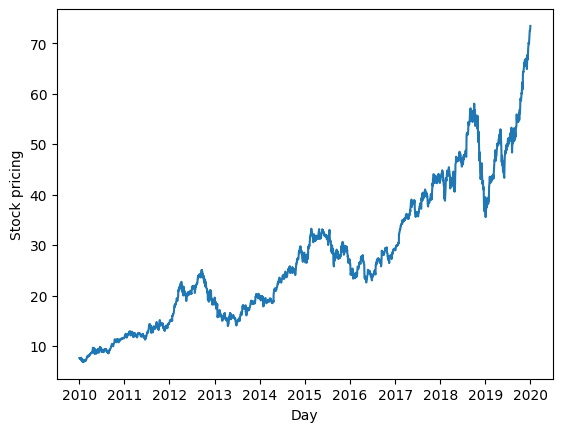

In [ ]:
# Function to prepare data for LSTM
def prepare_data(df, lookback):
    df_scaled = scaler.fit_transform(df)
    plt.plot(df.index,data['Close'])
    plt.xlabel('Day')
    plt.ylabel('Stock pricing')

    X, Y = [], []
    for i in range(lookback, len(df_scaled)):
        X.append(df_scaled[i-lookback:i, 0])
        Y.append(df_scaled[i, 0])
    return np.array(X), np.array(Y)

# Load and prepare data
data = download_and_process_stock_data('AAPL', '2010-01-01', '2020-01-01',path = '/content/drive/MyDrive/Colab Notebooks/Final project/yahoo finance dataset')



scaler = MinMaxScaler(feature_range=(-1, 1))

lookback = 1
X, y = prepare_data(data, lookback)
X_train, y_train = torch.Tensor(X[:-100]), torch.Tensor(y[:-100])
X_test, y_test = torch.Tensor(X[-100:]), torch.Tensor(y[-100:])

print (data.head(10))

# Hyperparameters for tuning
learning_rates = [0.001, 0.01,0.1]
hidden_layers = [50, 75,100]
batch_sizes = [10,16, 32, 64]

Training with LR=0.001, Hidden Units=50, Batch Size=10
Epoch 1 Loss: 0.20620104670524597
Epoch 2 Loss: 0.158897265791893
Epoch 3 Loss: 0.13508789241313934
Epoch 4 Loss: 0.0749274343252182
Epoch 5 Loss: 0.035519856959581375
Epoch 6 Loss: 0.18486696481704712
Epoch 7 Loss: 0.07644020766019821
Epoch 8 Loss: 0.30677878856658936
Epoch 9 Loss: 0.17034195363521576
Epoch 10 Loss: 0.07428490370512009
Epoch 11 Loss: 0.060529232025146484
Epoch 12 Loss: 0.1113453134894371
Epoch 13 Loss: 0.11252418905496597
Epoch 14 Loss: 0.04005474969744682
Epoch 15 Loss: 0.13907133042812347
Epoch 16 Loss: 0.12062738835811615
Epoch 17 Loss: 0.059023600071668625
Epoch 18 Loss: 0.09928720444440842
Epoch 19 Loss: 0.0767488181591034
Epoch 20 Loss: 0.06584573537111282
Epoch 21 Loss: 0.11533097922801971
Epoch 22 Loss: 0.20707567036151886
Epoch 23 Loss: 0.12394426017999649
Epoch 24 Loss: 0.2098609209060669
Epoch 25 Loss: 0.15820761024951935
Epoch 26 Loss: 0.10996337234973907
Epoch 27 Loss: 0.11672601848840714
Epoch 28 Los

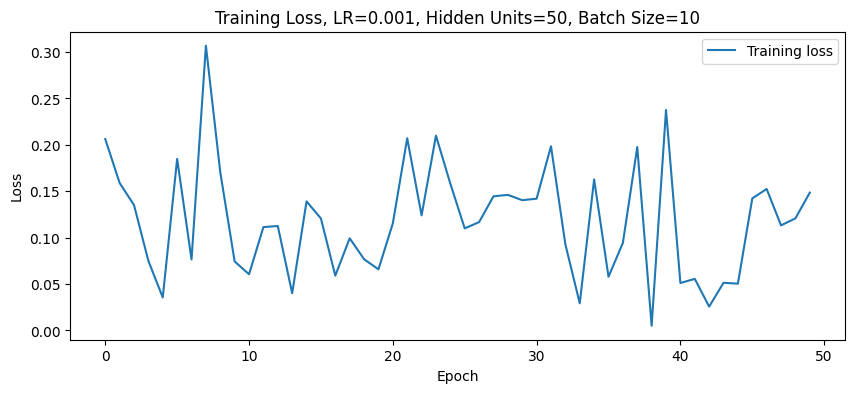

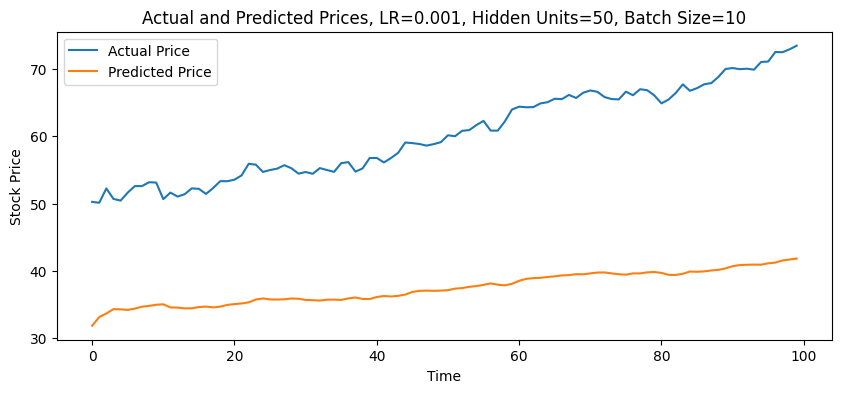

Training with LR=0.001, Hidden Units=50, Batch Size=16
Epoch 1 Loss: 0.29262521862983704
Epoch 2 Loss: 0.22669975459575653
Epoch 3 Loss: 0.11173338443040848
Epoch 4 Loss: 0.14909397065639496
Epoch 5 Loss: 0.1138586699962616
Epoch 6 Loss: 0.1620345413684845
Epoch 7 Loss: 0.12372302263975143
Epoch 8 Loss: 0.1154748871922493
Epoch 9 Loss: 0.09683927148580551
Epoch 10 Loss: 0.09862308204174042
Epoch 11 Loss: 0.1413143277168274
Epoch 12 Loss: 0.14672356843948364
Epoch 13 Loss: 0.09992480278015137
Epoch 14 Loss: 0.25359365344047546
Epoch 15 Loss: 0.21931792795658112
Epoch 16 Loss: 0.17350608110427856
Epoch 17 Loss: 0.16893786191940308
Epoch 18 Loss: 0.1243722140789032
Epoch 19 Loss: 0.12319030612707138
Epoch 20 Loss: 0.17366309463977814
Epoch 21 Loss: 0.1542864292860031
Epoch 22 Loss: 0.06280127167701721
Epoch 23 Loss: 0.06663064658641815
Epoch 24 Loss: 0.19604043662548065
Epoch 25 Loss: 0.13165144622325897
Epoch 26 Loss: 0.10679709911346436
Epoch 27 Loss: 0.20459602773189545
Epoch 28 Loss: 

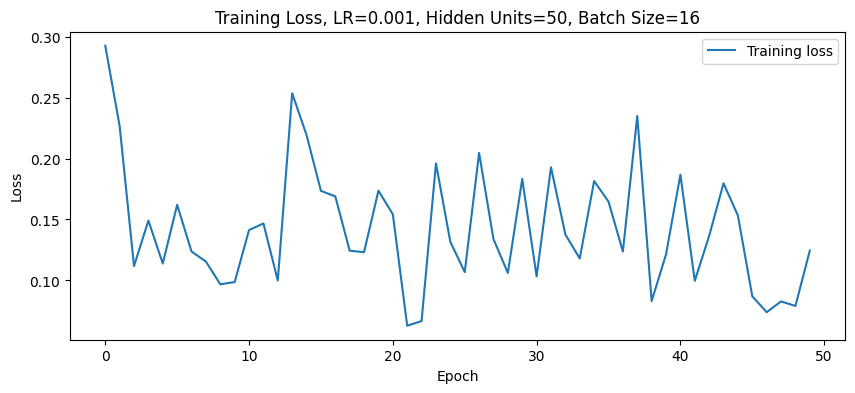

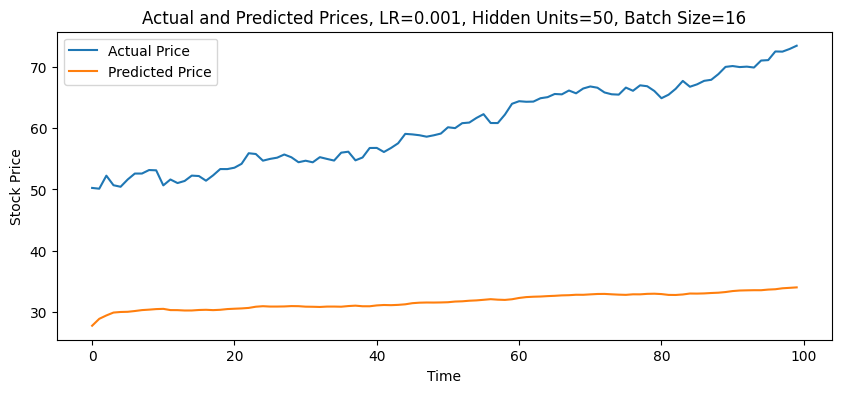

Training with LR=0.001, Hidden Units=50, Batch Size=32
Epoch 1 Loss: 0.24635209143161774
Epoch 2 Loss: 0.22996605932712555
Epoch 3 Loss: 0.20299233496189117
Epoch 4 Loss: 0.2011590301990509
Epoch 5 Loss: 0.20103174448013306
Epoch 6 Loss: 0.11152076721191406
Epoch 7 Loss: 0.11729549616575241
Epoch 8 Loss: 0.17539657652378082
Epoch 9 Loss: 0.16738636791706085
Epoch 10 Loss: 0.12412135303020477
Epoch 11 Loss: 0.13204915821552277
Epoch 12 Loss: 0.06739804148674011
Epoch 13 Loss: 0.1774415224790573
Epoch 14 Loss: 0.21089984476566315
Epoch 15 Loss: 0.200434148311615
Epoch 16 Loss: 0.10708414018154144
Epoch 17 Loss: 0.2683549225330353
Epoch 18 Loss: 0.1500864028930664
Epoch 19 Loss: 0.1065480038523674
Epoch 20 Loss: 0.14546892046928406
Epoch 21 Loss: 0.1295730620622635
Epoch 22 Loss: 0.1506611853837967
Epoch 23 Loss: 0.1890193670988083
Epoch 24 Loss: 0.1677706390619278
Epoch 25 Loss: 0.1160145252943039
Epoch 26 Loss: 0.10516250133514404
Epoch 27 Loss: 0.14844892919063568
Epoch 28 Loss: 0.1043

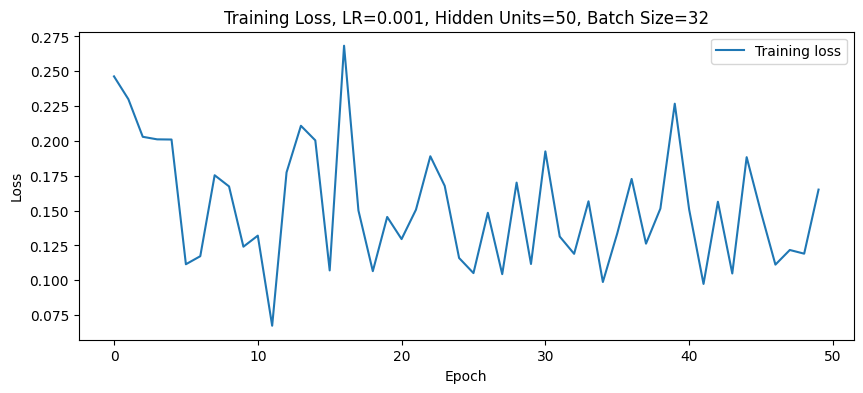

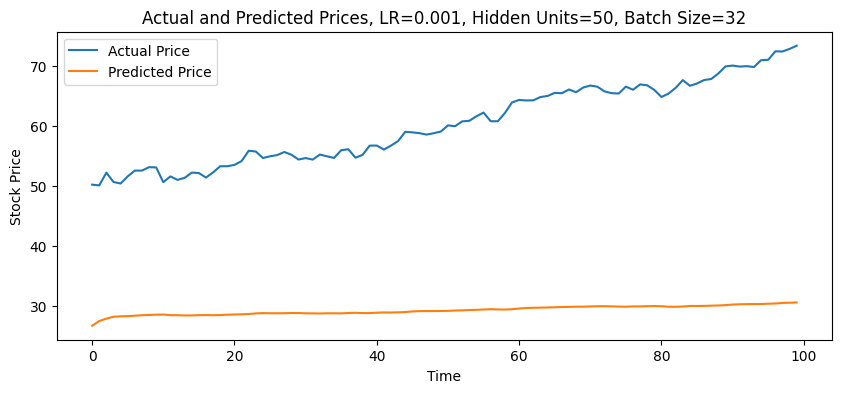

Training with LR=0.001, Hidden Units=50, Batch Size=64
Epoch 1 Loss: 0.35660892724990845
Epoch 2 Loss: 0.3290037214756012
Epoch 3 Loss: 0.2715834677219391
Epoch 4 Loss: 0.1896146684885025
Epoch 5 Loss: 0.18682995438575745
Epoch 6 Loss: 0.19274429976940155
Epoch 7 Loss: 0.1903063803911209
Epoch 8 Loss: 0.17256149649620056
Epoch 9 Loss: 0.225897416472435
Epoch 10 Loss: 0.16154944896697998
Epoch 11 Loss: 0.1989639401435852
Epoch 12 Loss: 0.16457095742225647
Epoch 13 Loss: 0.15539094805717468
Epoch 14 Loss: 0.1426132619380951
Epoch 15 Loss: 0.16374550759792328
Epoch 16 Loss: 0.14221708476543427
Epoch 17 Loss: 0.15073494613170624
Epoch 18 Loss: 0.1693049520254135
Epoch 19 Loss: 0.15289132297039032
Epoch 20 Loss: 0.12480685859918594
Epoch 21 Loss: 0.1367684304714203
Epoch 22 Loss: 0.17483605444431305
Epoch 23 Loss: 0.1662895530462265
Epoch 24 Loss: 0.15524348616600037
Epoch 25 Loss: 0.11453362554311752
Epoch 26 Loss: 0.1413774937391281
Epoch 27 Loss: 0.1105770543217659
Epoch 28 Loss: 0.16277

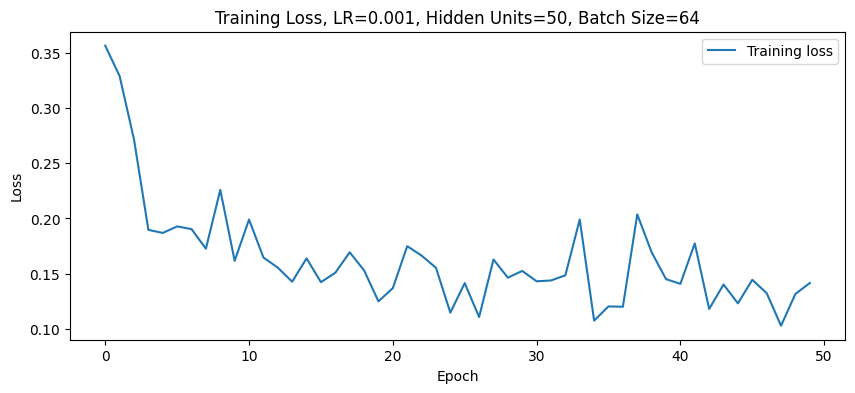

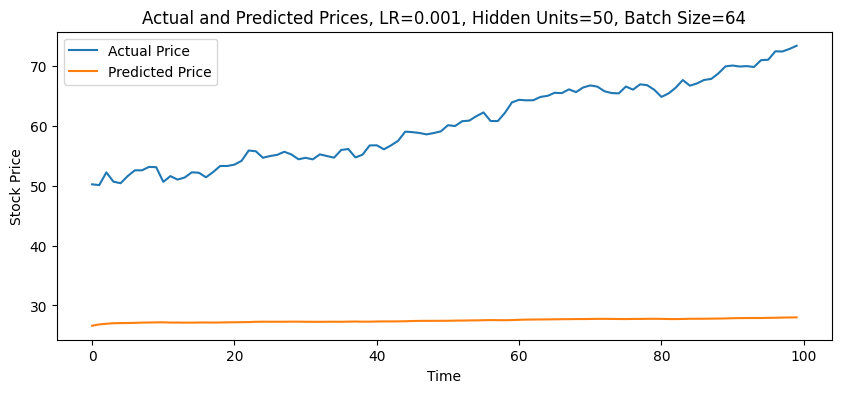

Training with LR=0.001, Hidden Units=75, Batch Size=10
Epoch 1 Loss: 0.42844071984291077
Epoch 2 Loss: 0.15164677798748016
Epoch 3 Loss: 0.15688849985599518
Epoch 4 Loss: 0.1885875165462494
Epoch 5 Loss: 0.20256240665912628
Epoch 6 Loss: 0.14147526025772095
Epoch 7 Loss: 0.12763124704360962
Epoch 8 Loss: 0.2461807280778885
Epoch 9 Loss: 0.10173632949590683
Epoch 10 Loss: 0.1334265172481537
Epoch 11 Loss: 0.2246643602848053
Epoch 12 Loss: 0.2211214005947113
Epoch 13 Loss: 0.07415055483579636
Epoch 14 Loss: 0.08817167580127716
Epoch 15 Loss: 0.08043809235095978
Epoch 16 Loss: 0.11262746155261993
Epoch 17 Loss: 0.060347575694322586
Epoch 18 Loss: 0.11126317828893661
Epoch 19 Loss: 0.15708687901496887
Epoch 20 Loss: 0.0786258727312088
Epoch 21 Loss: 0.14142629504203796
Epoch 22 Loss: 0.18295398354530334
Epoch 23 Loss: 0.09798641502857208
Epoch 24 Loss: 0.0724673792719841
Epoch 25 Loss: 0.0843299999833107
Epoch 26 Loss: 0.09743809700012207
Epoch 27 Loss: 0.1853371113538742
Epoch 28 Loss: 0.

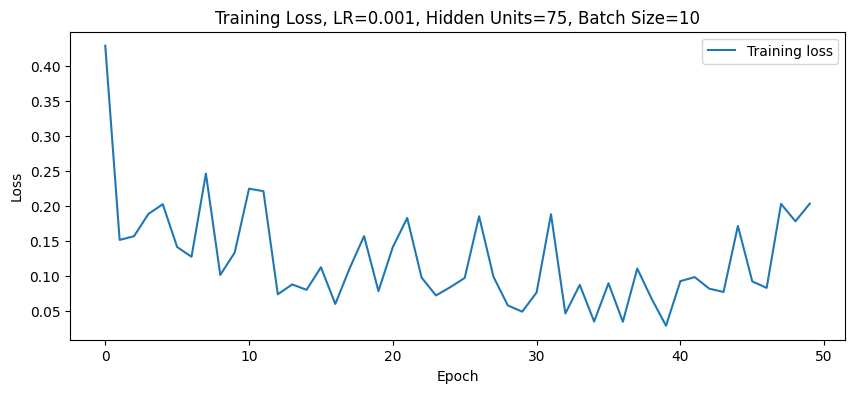

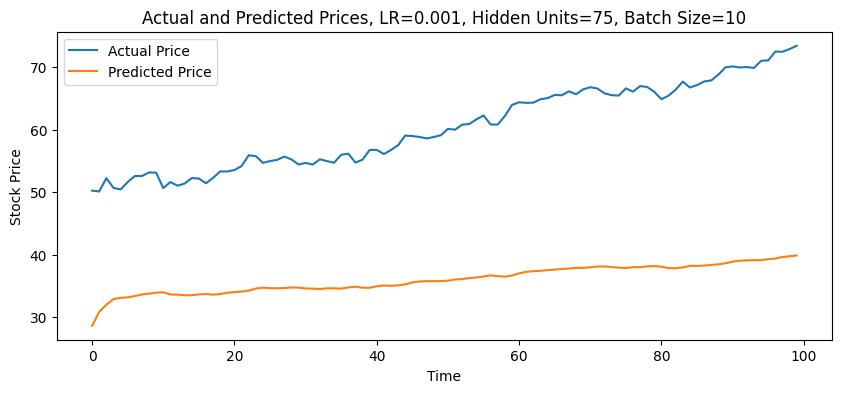

Training with LR=0.001, Hidden Units=75, Batch Size=16
Epoch 1 Loss: 0.26402023434638977
Epoch 2 Loss: 0.16420915722846985
Epoch 3 Loss: 0.1909283697605133
Epoch 4 Loss: 0.1650346964597702
Epoch 5 Loss: 0.0921226218342781
Epoch 6 Loss: 0.16200289130210876
Epoch 7 Loss: 0.14360672235488892
Epoch 8 Loss: 0.11356701701879501
Epoch 9 Loss: 0.12649904191493988
Epoch 10 Loss: 0.15727488696575165
Epoch 11 Loss: 0.15545038878917694
Epoch 12 Loss: 0.13734044134616852
Epoch 13 Loss: 0.1138080582022667
Epoch 14 Loss: 0.12643404304981232
Epoch 15 Loss: 0.1341351717710495
Epoch 16 Loss: 0.11942998319864273
Epoch 17 Loss: 0.138319730758667
Epoch 18 Loss: 0.1318030059337616
Epoch 19 Loss: 0.10509579628705978
Epoch 20 Loss: 0.14220105111598969
Epoch 21 Loss: 0.10095613449811935
Epoch 22 Loss: 0.1447618007659912
Epoch 23 Loss: 0.16093142330646515
Epoch 24 Loss: 0.18176667392253876
Epoch 25 Loss: 0.10801561176776886
Epoch 26 Loss: 0.09258747100830078
Epoch 27 Loss: 0.12604711949825287
Epoch 28 Loss: 0.1

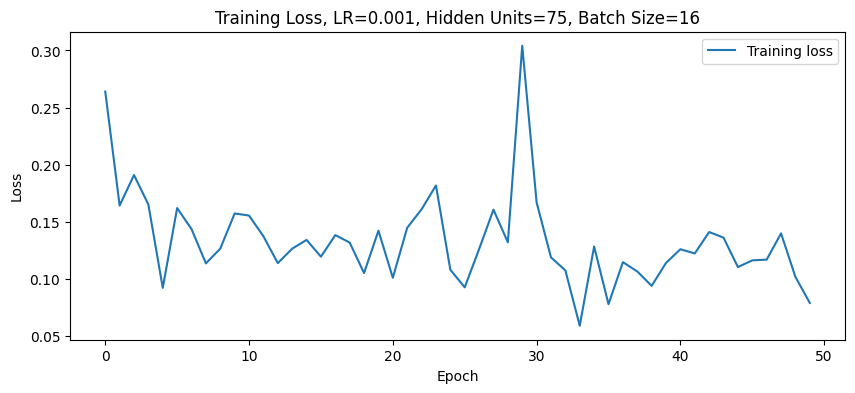

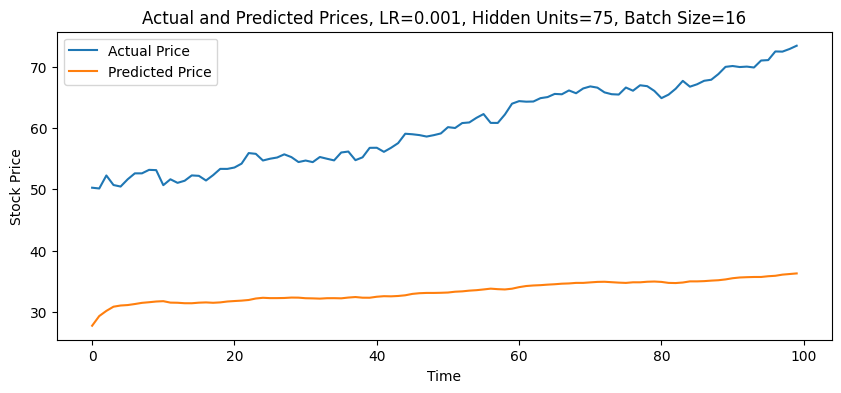

Training with LR=0.001, Hidden Units=75, Batch Size=32
Epoch 1 Loss: 0.22272440791130066
Epoch 2 Loss: 0.2888296842575073
Epoch 3 Loss: 0.1795228123664856
Epoch 4 Loss: 0.17640270292758942
Epoch 5 Loss: 0.10550417006015778
Epoch 6 Loss: 0.15300673246383667
Epoch 7 Loss: 0.12012114375829697
Epoch 8 Loss: 0.15250959992408752
Epoch 9 Loss: 0.15042081475257874
Epoch 10 Loss: 0.1256963610649109
Epoch 11 Loss: 0.13679717481136322
Epoch 12 Loss: 0.22324462234973907
Epoch 13 Loss: 0.12266401946544647
Epoch 14 Loss: 0.14004312455654144
Epoch 15 Loss: 0.09113359451293945
Epoch 16 Loss: 0.22285154461860657
Epoch 17 Loss: 0.18862169981002808
Epoch 18 Loss: 0.11583935469388962
Epoch 19 Loss: 0.14242437481880188
Epoch 20 Loss: 0.19407616555690765
Epoch 21 Loss: 0.14049766957759857
Epoch 22 Loss: 0.12743836641311646
Epoch 23 Loss: 0.14935117959976196
Epoch 24 Loss: 0.10915957391262054
Epoch 25 Loss: 0.09375783801078796
Epoch 26 Loss: 0.15765497088432312
Epoch 27 Loss: 0.14002510905265808
Epoch 28 Los

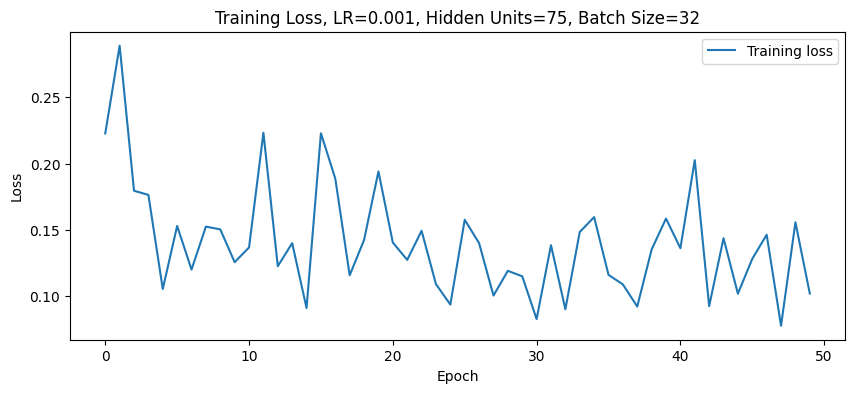

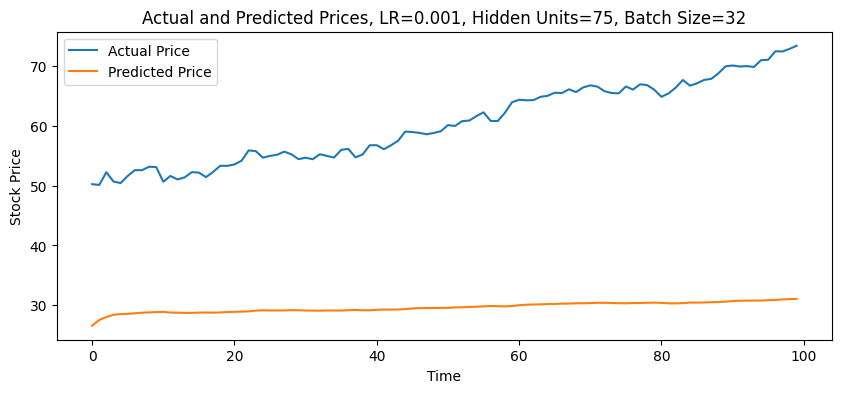

Training with LR=0.001, Hidden Units=75, Batch Size=64
Epoch 1 Loss: 0.239924356341362
Epoch 2 Loss: 0.2042582929134369
Epoch 3 Loss: 0.19940400123596191
Epoch 4 Loss: 0.2331652194261551
Epoch 5 Loss: 0.15805664658546448
Epoch 6 Loss: 0.14223037660121918
Epoch 7 Loss: 0.15317687392234802
Epoch 8 Loss: 0.14256085455417633
Epoch 9 Loss: 0.17060230672359467
Epoch 10 Loss: 0.13491606712341309
Epoch 11 Loss: 0.14249128103256226
Epoch 12 Loss: 0.13699352741241455
Epoch 13 Loss: 0.1675342470407486
Epoch 14 Loss: 0.16216382384300232
Epoch 15 Loss: 0.14203563332557678
Epoch 16 Loss: 0.1174529641866684
Epoch 17 Loss: 0.13362166285514832
Epoch 18 Loss: 0.1501127928495407
Epoch 19 Loss: 0.12626959383487701
Epoch 20 Loss: 0.15538623929023743
Epoch 21 Loss: 0.17951181530952454
Epoch 22 Loss: 0.13168072700500488
Epoch 23 Loss: 0.14835163950920105
Epoch 24 Loss: 0.12748657166957855
Epoch 25 Loss: 0.13445289433002472
Epoch 26 Loss: 0.14009283483028412
Epoch 27 Loss: 0.1127631738781929
Epoch 28 Loss: 0.

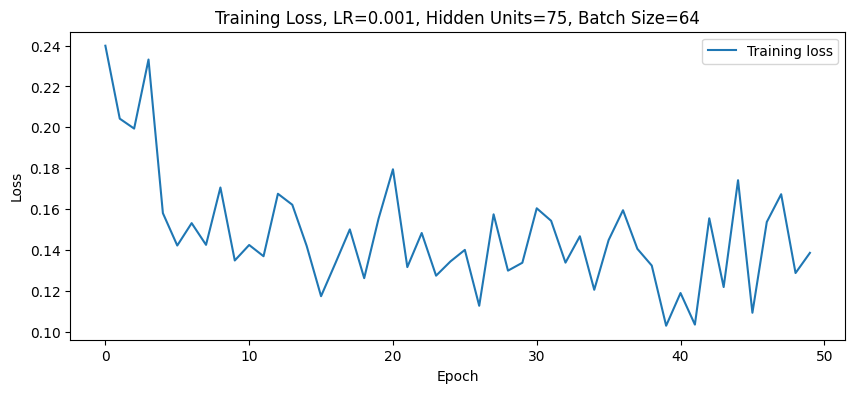

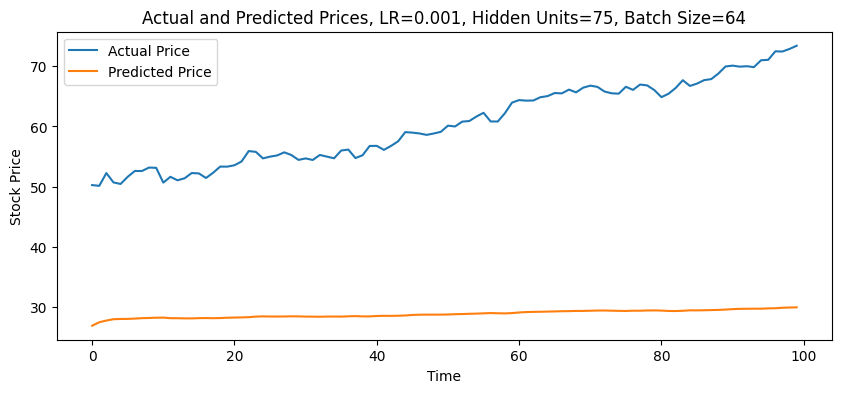

Training with LR=0.001, Hidden Units=100, Batch Size=10
Epoch 1 Loss: 0.14319297671318054
Epoch 2 Loss: 0.171161949634552
Epoch 3 Loss: 0.16367661952972412
Epoch 4 Loss: 0.3580654561519623
Epoch 5 Loss: 0.1465698778629303
Epoch 6 Loss: 0.1147855743765831
Epoch 7 Loss: 0.0930435061454773
Epoch 8 Loss: 0.17975813150405884
Epoch 9 Loss: 0.0972931757569313
Epoch 10 Loss: 0.10459452867507935
Epoch 11 Loss: 0.07139800488948822
Epoch 12 Loss: 0.25052589178085327
Epoch 13 Loss: 0.10037747770547867
Epoch 14 Loss: 0.05736909434199333
Epoch 15 Loss: 0.08025351911783218
Epoch 16 Loss: 0.1467132270336151
Epoch 17 Loss: 0.10028235614299774
Epoch 18 Loss: 0.12717628479003906
Epoch 19 Loss: 0.18782176077365875
Epoch 20 Loss: 0.12369249761104584
Epoch 21 Loss: 0.1115361675620079
Epoch 22 Loss: 0.22235628962516785
Epoch 23 Loss: 0.18270130455493927
Epoch 24 Loss: 0.08837147057056427
Epoch 25 Loss: 0.0979100838303566
Epoch 26 Loss: 0.18554797768592834
Epoch 27 Loss: 0.18061001598834991
Epoch 28 Loss: 0.1

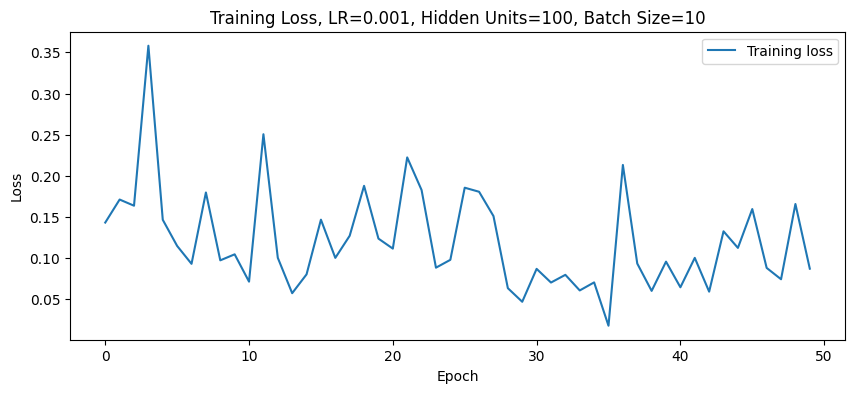

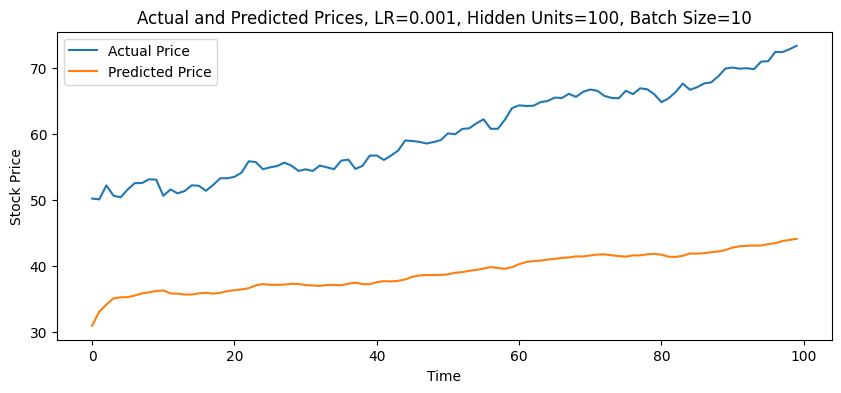

Training with LR=0.001, Hidden Units=100, Batch Size=16
Epoch 1 Loss: 0.1252925992012024
Epoch 2 Loss: 0.18267475068569183
Epoch 3 Loss: 0.1372130960226059
Epoch 4 Loss: 0.16900227963924408
Epoch 5 Loss: 0.10819312930107117
Epoch 6 Loss: 0.16762958467006683
Epoch 7 Loss: 0.17031791806221008
Epoch 8 Loss: 0.14018745720386505
Epoch 9 Loss: 0.14191381633281708
Epoch 10 Loss: 0.22439809143543243
Epoch 11 Loss: 0.18973340094089508
Epoch 12 Loss: 0.2434740960597992
Epoch 13 Loss: 0.2078121453523636
Epoch 14 Loss: 0.047486353665590286
Epoch 15 Loss: 0.12781520187854767
Epoch 16 Loss: 0.04834596812725067
Epoch 17 Loss: 0.14083538949489594
Epoch 18 Loss: 0.1782955825328827
Epoch 19 Loss: 0.04944442957639694
Epoch 20 Loss: 0.10851576924324036
Epoch 21 Loss: 0.15194109082221985
Epoch 22 Loss: 0.15949027240276337
Epoch 23 Loss: 0.08917980641126633
Epoch 24 Loss: 0.12667019665241241
Epoch 25 Loss: 0.09248067438602448
Epoch 26 Loss: 0.16275586187839508
Epoch 27 Loss: 0.2177259624004364
Epoch 28 Loss

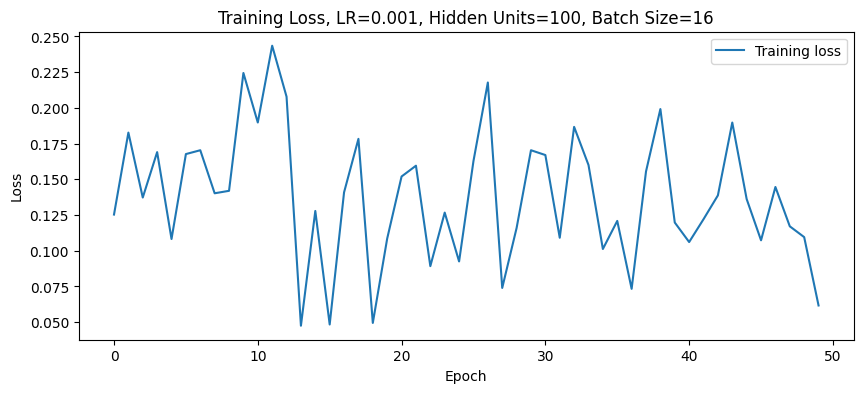

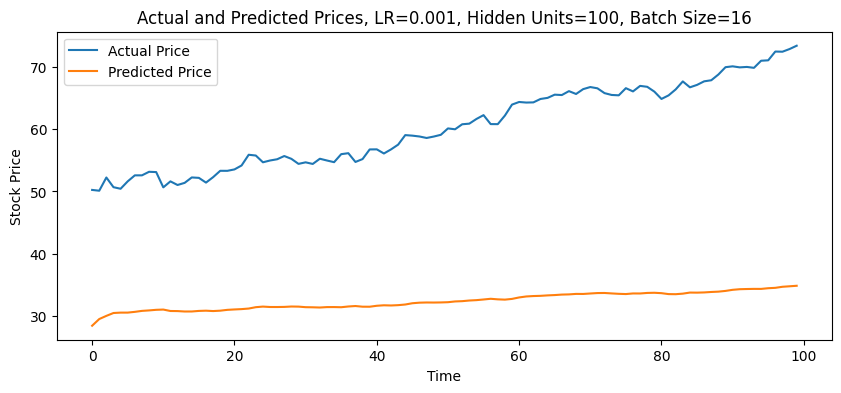

Training with LR=0.001, Hidden Units=100, Batch Size=32
Epoch 1 Loss: 0.2518022656440735
Epoch 2 Loss: 0.20165911316871643
Epoch 3 Loss: 0.19257226586341858
Epoch 4 Loss: 0.19143056869506836
Epoch 5 Loss: 0.1304345577955246
Epoch 6 Loss: 0.2051641196012497
Epoch 7 Loss: 0.1352880597114563
Epoch 8 Loss: 0.1372208446264267
Epoch 9 Loss: 0.07536937296390533
Epoch 10 Loss: 0.16071388125419617
Epoch 11 Loss: 0.13854093849658966
Epoch 12 Loss: 0.11728668212890625
Epoch 13 Loss: 0.18166516721248627
Epoch 14 Loss: 0.1402316838502884
Epoch 15 Loss: 0.11466523259878159
Epoch 16 Loss: 0.17410282790660858
Epoch 17 Loss: 0.09246435761451721
Epoch 18 Loss: 0.19674564898014069
Epoch 19 Loss: 0.10942748188972473
Epoch 20 Loss: 0.0921722948551178
Epoch 21 Loss: 0.0839122086763382
Epoch 22 Loss: 0.15380272269248962
Epoch 23 Loss: 0.10356501489877701
Epoch 24 Loss: 0.15388108789920807
Epoch 25 Loss: 0.12863963842391968
Epoch 26 Loss: 0.17342813313007355
Epoch 27 Loss: 0.09663711488246918
Epoch 28 Loss: 0

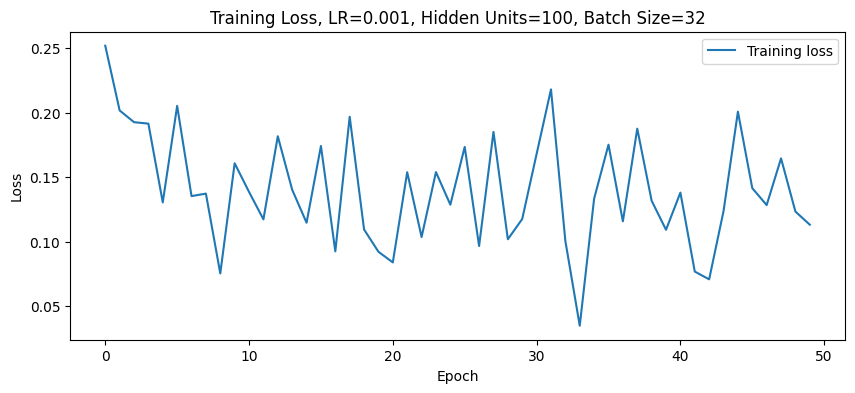

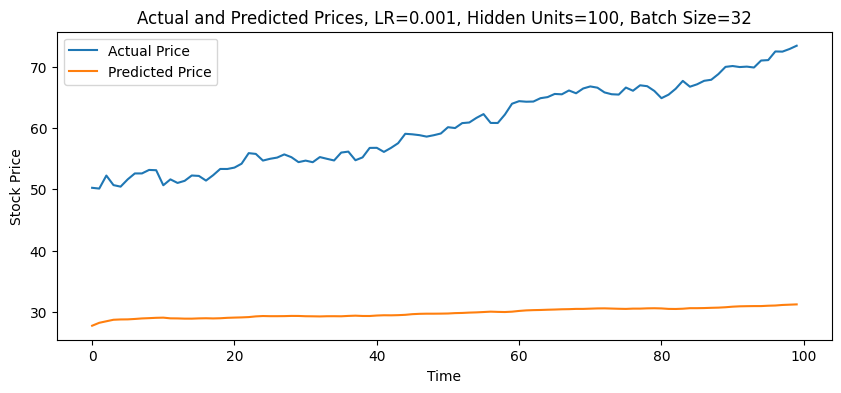

Training with LR=0.001, Hidden Units=100, Batch Size=64
Epoch 1 Loss: 0.26920250058174133
Epoch 2 Loss: 0.2740844488143921
Epoch 3 Loss: 0.2225649356842041
Epoch 4 Loss: 0.26357316970825195
Epoch 5 Loss: 0.23556466400623322
Epoch 6 Loss: 0.18429751694202423
Epoch 7 Loss: 0.187205970287323
Epoch 8 Loss: 0.17351694405078888
Epoch 9 Loss: 0.14100003242492676
Epoch 10 Loss: 0.14471352100372314
Epoch 11 Loss: 0.13708895444869995
Epoch 12 Loss: 0.15809516608715057
Epoch 13 Loss: 0.16518504917621613
Epoch 14 Loss: 0.13829322159290314
Epoch 15 Loss: 0.138745978474617
Epoch 16 Loss: 0.13860942423343658
Epoch 17 Loss: 0.1263507753610611
Epoch 18 Loss: 0.1340900957584381
Epoch 19 Loss: 0.10997737944126129
Epoch 20 Loss: 0.14387379586696625
Epoch 21 Loss: 0.1293252855539322
Epoch 22 Loss: 0.12202346324920654
Epoch 23 Loss: 0.15570273995399475
Epoch 24 Loss: 0.15801307559013367
Epoch 25 Loss: 0.16573037207126617
Epoch 26 Loss: 0.1377207636833191
Epoch 27 Loss: 0.1559027135372162
Epoch 28 Loss: 0.13

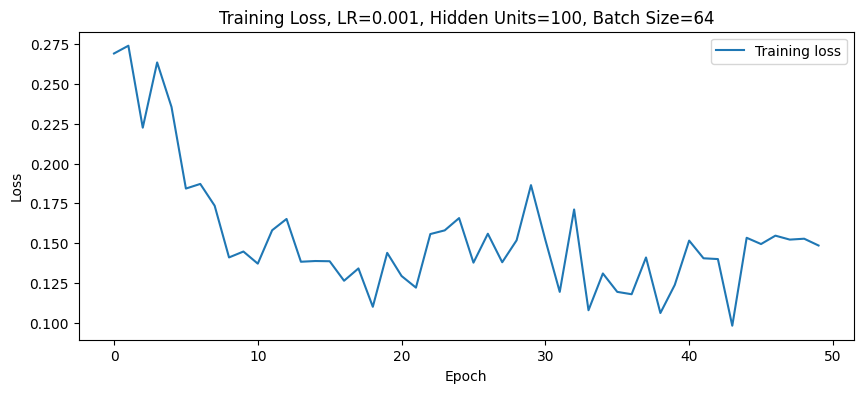

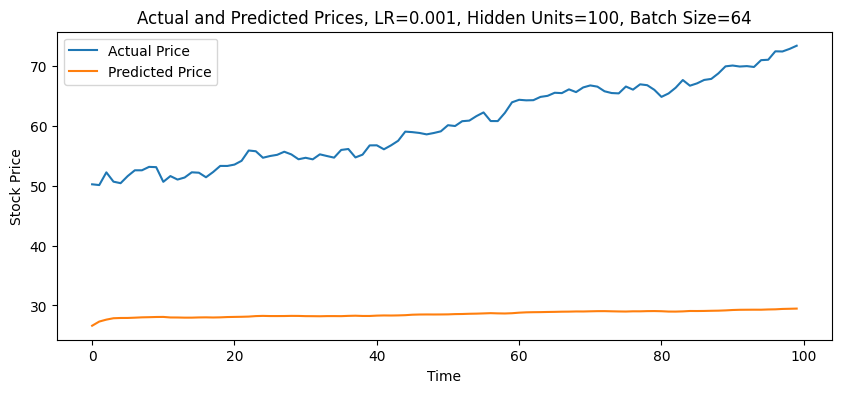

Training with LR=0.01, Hidden Units=50, Batch Size=10
Epoch 1 Loss: 0.19050323963165283
Epoch 2 Loss: 0.06485258042812347
Epoch 3 Loss: 0.13661997020244598
Epoch 4 Loss: 0.11882340908050537
Epoch 5 Loss: 0.10436643660068512
Epoch 6 Loss: 0.02793087624013424
Epoch 7 Loss: 0.09790760278701782
Epoch 8 Loss: 0.01451476663351059
Epoch 9 Loss: 0.07136133313179016
Epoch 10 Loss: 0.04149971529841423
Epoch 11 Loss: 0.012828837148845196
Epoch 12 Loss: 0.06313817948102951
Epoch 13 Loss: 0.00878736563026905
Epoch 14 Loss: 0.024114172905683517
Epoch 15 Loss: 0.002243443625047803
Epoch 16 Loss: 0.02359401434659958
Epoch 17 Loss: 0.022853035479784012
Epoch 18 Loss: 0.008478647097945213
Epoch 19 Loss: 0.007342834956943989
Epoch 20 Loss: 0.0075719296000897884
Epoch 21 Loss: 0.009514556266367435
Epoch 22 Loss: 0.007591329514980316
Epoch 23 Loss: 0.0063127330504357815
Epoch 24 Loss: 0.002319418592378497
Epoch 25 Loss: 0.011063425801694393
Epoch 26 Loss: 0.004962730221450329
Epoch 27 Loss: 0.0071867690421

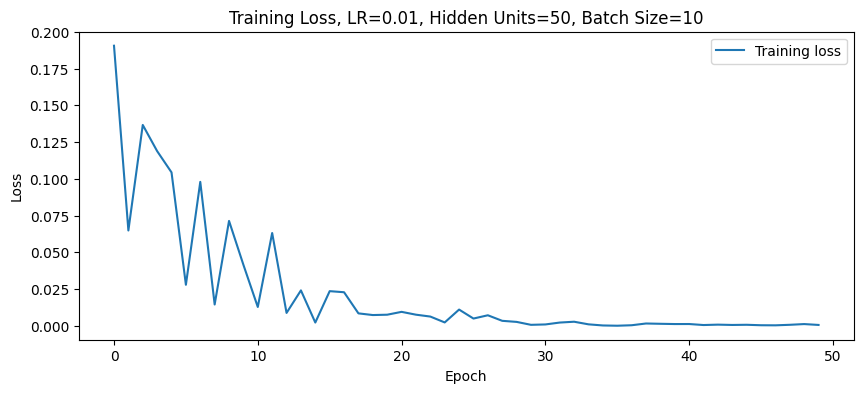

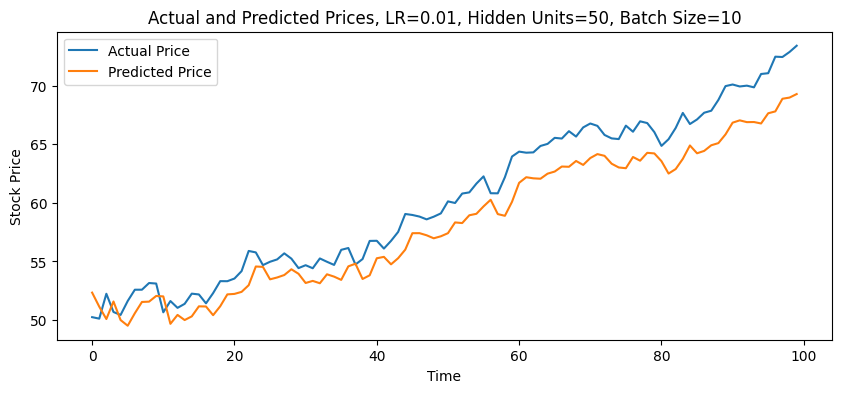

Training with LR=0.01, Hidden Units=50, Batch Size=16
Epoch 1 Loss: 0.2203560620546341
Epoch 2 Loss: 0.12028564512729645
Epoch 3 Loss: 0.08260159939527512
Epoch 4 Loss: 0.12636798620224
Epoch 5 Loss: 0.11058689653873444
Epoch 6 Loss: 0.12310799956321716
Epoch 7 Loss: 0.15725894272327423
Epoch 8 Loss: 0.1430552899837494
Epoch 9 Loss: 0.0792386457324028
Epoch 10 Loss: 0.07473383843898773
Epoch 11 Loss: 0.07130729407072067
Epoch 12 Loss: 0.040696773678064346
Epoch 13 Loss: 0.024863896891474724
Epoch 14 Loss: 0.06617806851863861
Epoch 15 Loss: 0.036531660705804825
Epoch 16 Loss: 0.05819298326969147
Epoch 17 Loss: 0.029839547351002693
Epoch 18 Loss: 0.04138188809156418
Epoch 19 Loss: 0.013931838795542717
Epoch 20 Loss: 0.018445702269673347
Epoch 21 Loss: 0.01116091851145029
Epoch 22 Loss: 0.010642423294484615
Epoch 23 Loss: 0.012751799076795578
Epoch 24 Loss: 0.022529490292072296
Epoch 25 Loss: 0.028234627097845078
Epoch 26 Loss: 0.024428503587841988
Epoch 27 Loss: 0.00843796320259571
Epoch

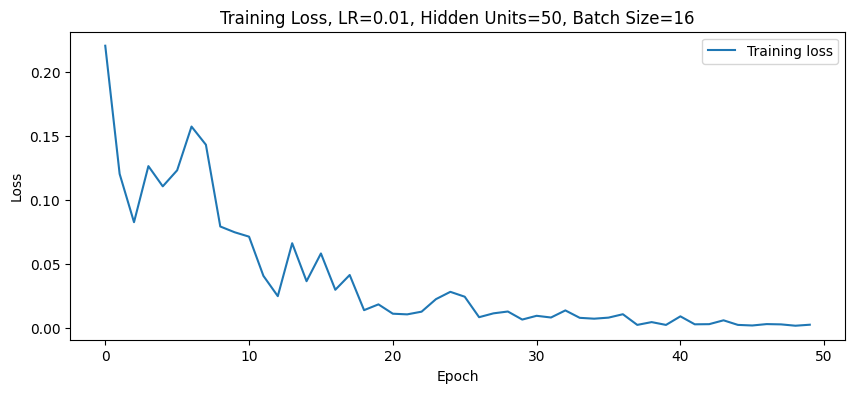

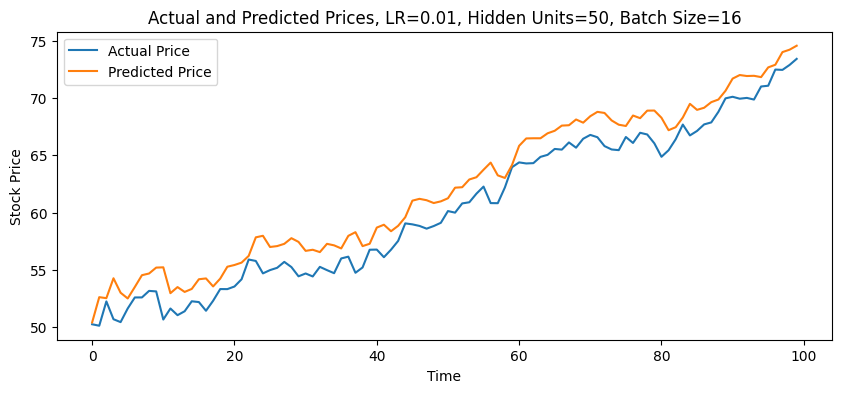

Training with LR=0.01, Hidden Units=50, Batch Size=32
Epoch 1 Loss: 0.16298216581344604
Epoch 2 Loss: 0.13813088834285736
Epoch 3 Loss: 0.12706734240055084
Epoch 4 Loss: 0.08632273226976395
Epoch 5 Loss: 0.13337180018424988
Epoch 6 Loss: 0.10143845528364182
Epoch 7 Loss: 0.1500578671693802
Epoch 8 Loss: 0.15744492411613464
Epoch 9 Loss: 0.15772607922554016
Epoch 10 Loss: 0.10068880766630173
Epoch 11 Loss: 0.18643006682395935
Epoch 12 Loss: 0.0731547623872757
Epoch 13 Loss: 0.09905172139406204
Epoch 14 Loss: 0.05526179075241089
Epoch 15 Loss: 0.0764293223619461
Epoch 16 Loss: 0.05236641690135002
Epoch 17 Loss: 0.10171033442020416
Epoch 18 Loss: 0.0851781815290451
Epoch 19 Loss: 0.09044066816568375
Epoch 20 Loss: 0.11392143368721008
Epoch 21 Loss: 0.11036524176597595
Epoch 22 Loss: 0.06014932319521904
Epoch 23 Loss: 0.07360566407442093
Epoch 24 Loss: 0.07103795558214188
Epoch 25 Loss: 0.05003504827618599
Epoch 26 Loss: 0.05873073264956474
Epoch 27 Loss: 0.022430002689361572
Epoch 28 Loss

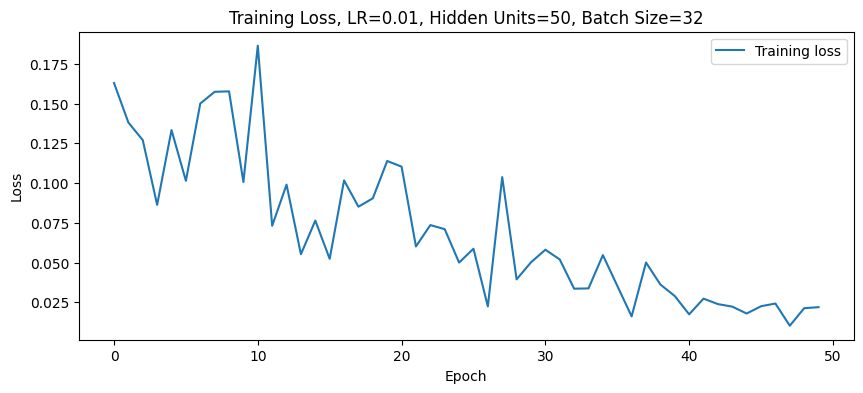

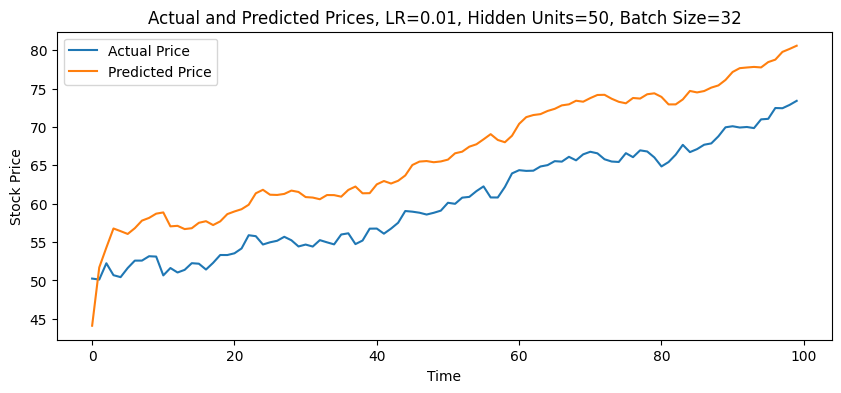

Training with LR=0.01, Hidden Units=50, Batch Size=64
Epoch 1 Loss: 0.16221119463443756
Epoch 2 Loss: 0.15917454659938812
Epoch 3 Loss: 0.15947143733501434
Epoch 4 Loss: 0.11804313212633133
Epoch 5 Loss: 0.16017699241638184
Epoch 6 Loss: 0.11503805220127106
Epoch 7 Loss: 0.14146529138088226
Epoch 8 Loss: 0.12057320773601532
Epoch 9 Loss: 0.10861843079328537
Epoch 10 Loss: 0.1088414117693901
Epoch 11 Loss: 0.10465793311595917
Epoch 12 Loss: 0.14715664088726044
Epoch 13 Loss: 0.17689521610736847
Epoch 14 Loss: 0.15693752467632294
Epoch 15 Loss: 0.10806989669799805
Epoch 16 Loss: 0.1597309559583664
Epoch 17 Loss: 0.12863941490650177
Epoch 18 Loss: 0.12263169884681702
Epoch 19 Loss: 0.09710928052663803
Epoch 20 Loss: 0.131313756108284
Epoch 21 Loss: 0.11197660118341446
Epoch 22 Loss: 0.1283566802740097
Epoch 23 Loss: 0.13352923095226288
Epoch 24 Loss: 0.11272379755973816
Epoch 25 Loss: 0.12085553258657455
Epoch 26 Loss: 0.11882803589105606
Epoch 27 Loss: 0.07671613246202469
Epoch 28 Loss: 

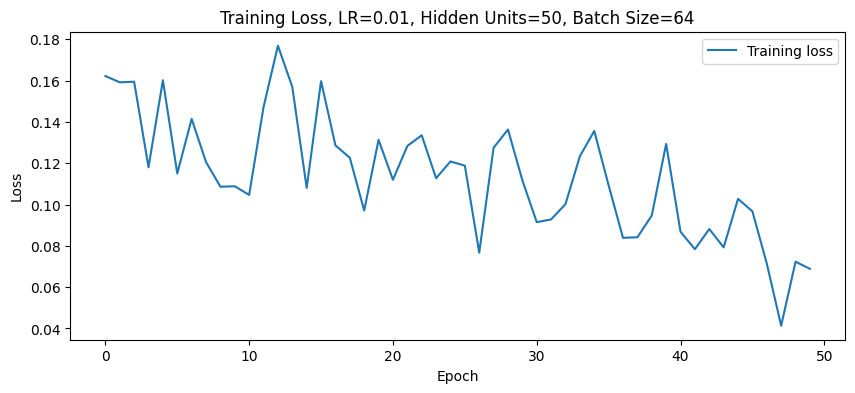

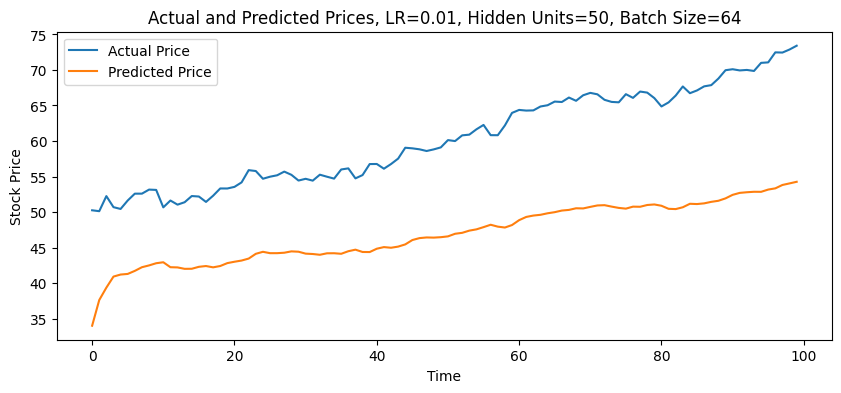

Training with LR=0.01, Hidden Units=75, Batch Size=10
Epoch 1 Loss: 0.05118424817919731
Epoch 2 Loss: 0.09368132799863815
Epoch 3 Loss: 0.08875130116939545
Epoch 4 Loss: 0.14018073678016663
Epoch 5 Loss: 0.055985402315855026
Epoch 6 Loss: 0.07277894765138626
Epoch 7 Loss: 0.10749222338199615
Epoch 8 Loss: 0.05331040546298027
Epoch 9 Loss: 0.08819679170846939
Epoch 10 Loss: 0.09789696335792542
Epoch 11 Loss: 0.08037246018648148
Epoch 12 Loss: 0.049652550369501114
Epoch 13 Loss: 0.048603273928165436
Epoch 14 Loss: 0.01988428831100464
Epoch 15 Loss: 0.031006544828414917
Epoch 16 Loss: 0.010424861684441566
Epoch 17 Loss: 0.011052096262574196
Epoch 18 Loss: 0.0002528739278204739
Epoch 19 Loss: 0.013082432560622692
Epoch 20 Loss: 0.009127393364906311
Epoch 21 Loss: 0.01377153117209673
Epoch 22 Loss: 0.015347814187407494
Epoch 23 Loss: 0.01010957546532154
Epoch 24 Loss: 0.00673096626996994
Epoch 25 Loss: 0.0011758358450606465
Epoch 26 Loss: 0.004244648851454258
Epoch 27 Loss: 0.00446285959333

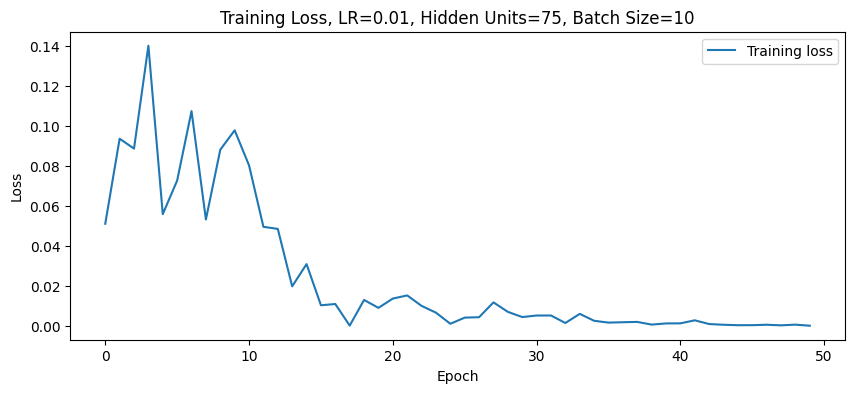

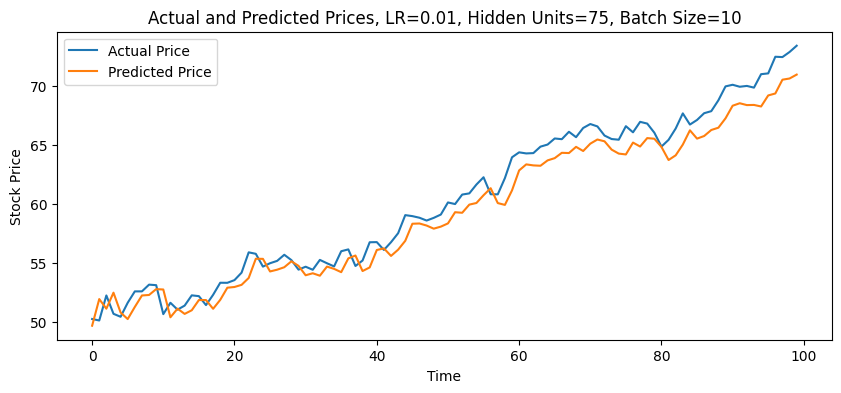

Training with LR=0.01, Hidden Units=75, Batch Size=16
Epoch 1 Loss: 0.09748269617557526
Epoch 2 Loss: 0.16941480338573456
Epoch 3 Loss: 0.08599475026130676
Epoch 4 Loss: 0.11667008697986603
Epoch 5 Loss: 0.1062919870018959
Epoch 6 Loss: 0.14823846518993378
Epoch 7 Loss: 0.1362179070711136
Epoch 8 Loss: 0.10875435918569565
Epoch 9 Loss: 0.1312539279460907
Epoch 10 Loss: 0.0772300735116005
Epoch 11 Loss: 0.07263407111167908
Epoch 12 Loss: 0.048088349401950836
Epoch 13 Loss: 0.0532628558576107
Epoch 14 Loss: 0.0638437569141388
Epoch 15 Loss: 0.051487188786268234
Epoch 16 Loss: 0.030697885900735855
Epoch 17 Loss: 0.03163227438926697
Epoch 18 Loss: 0.02613040804862976
Epoch 19 Loss: 0.020244095474481583
Epoch 20 Loss: 0.016240457072854042
Epoch 21 Loss: 0.015993164852261543
Epoch 22 Loss: 0.010669304057955742
Epoch 23 Loss: 0.007160860113799572
Epoch 24 Loss: 0.022421663627028465
Epoch 25 Loss: 0.022980544716119766
Epoch 26 Loss: 0.011187261901795864
Epoch 27 Loss: 0.015146649442613125
Epoc

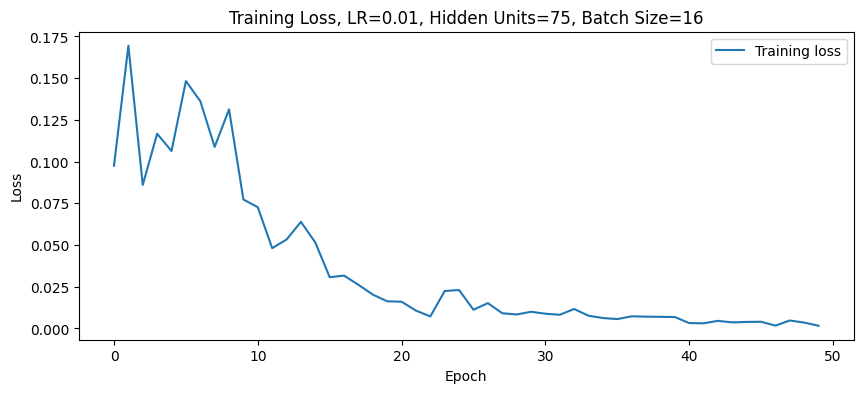

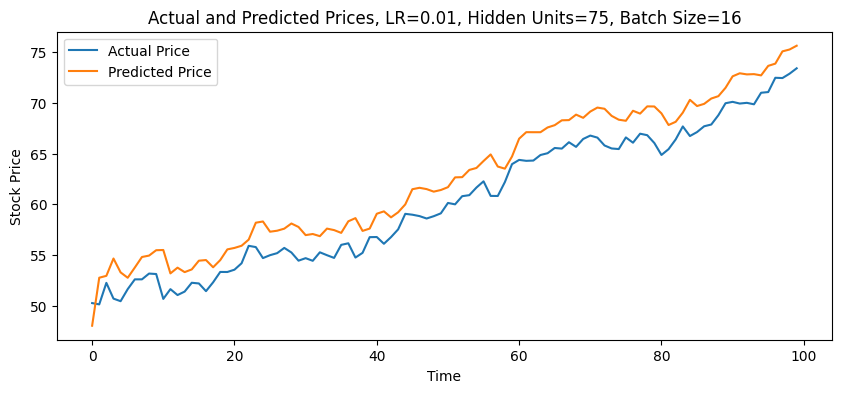

Training with LR=0.01, Hidden Units=75, Batch Size=32
Epoch 1 Loss: 0.20740722119808197
Epoch 2 Loss: 0.08696289360523224
Epoch 3 Loss: 0.1268806904554367
Epoch 4 Loss: 0.14680545032024384
Epoch 5 Loss: 0.14185360074043274
Epoch 6 Loss: 0.1531142294406891
Epoch 7 Loss: 0.17900754511356354
Epoch 8 Loss: 0.11863333731889725
Epoch 9 Loss: 0.12336268275976181
Epoch 10 Loss: 0.12111177295446396
Epoch 11 Loss: 0.1314147263765335
Epoch 12 Loss: 0.157213494181633
Epoch 13 Loss: 0.12483929842710495
Epoch 14 Loss: 0.18253888189792633
Epoch 15 Loss: 0.11515405029058456
Epoch 16 Loss: 0.08102699369192123
Epoch 17 Loss: 0.11655209958553314
Epoch 18 Loss: 0.09847739338874817
Epoch 19 Loss: 0.11154439300298691
Epoch 20 Loss: 0.06178639084100723
Epoch 21 Loss: 0.13155525922775269
Epoch 22 Loss: 0.06537415087223053
Epoch 23 Loss: 0.12979714572429657
Epoch 24 Loss: 0.02552388794720173
Epoch 25 Loss: 0.06312497705221176
Epoch 26 Loss: 0.05130796507000923
Epoch 27 Loss: 0.06761778146028519
Epoch 28 Loss: 

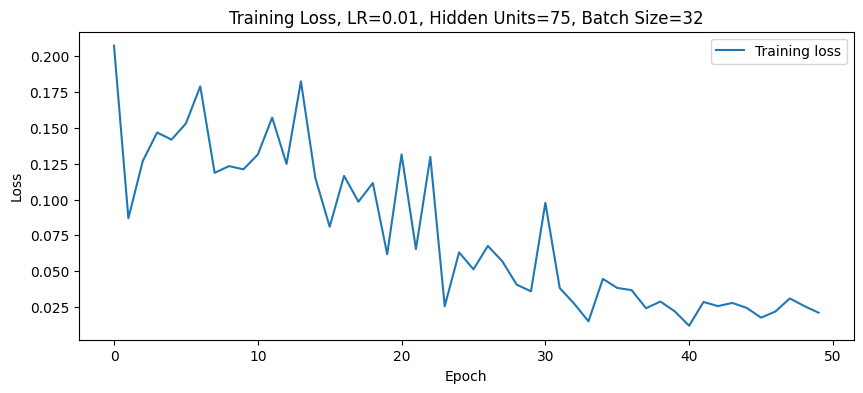

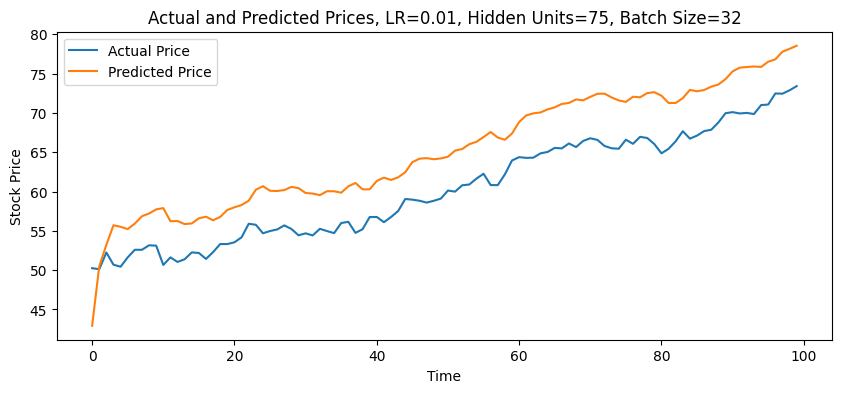

Training with LR=0.01, Hidden Units=75, Batch Size=64
Epoch 1 Loss: 0.1391594409942627
Epoch 2 Loss: 0.18501773476600647
Epoch 3 Loss: 0.12942612171173096
Epoch 4 Loss: 0.16123515367507935
Epoch 5 Loss: 0.11658833175897598
Epoch 6 Loss: 0.14672572910785675
Epoch 7 Loss: 0.13689427077770233
Epoch 8 Loss: 0.12679360806941986
Epoch 9 Loss: 0.1445855349302292
Epoch 10 Loss: 0.12254893779754639
Epoch 11 Loss: 0.11296422779560089
Epoch 12 Loss: 0.1011965200304985
Epoch 13 Loss: 0.10532406717538834
Epoch 14 Loss: 0.1125691682100296
Epoch 15 Loss: 0.12587526440620422
Epoch 16 Loss: 0.1101650819182396
Epoch 17 Loss: 0.09825631231069565
Epoch 18 Loss: 0.14021161198616028
Epoch 19 Loss: 0.10328694432973862
Epoch 20 Loss: 0.08292927592992783
Epoch 21 Loss: 0.09516558796167374
Epoch 22 Loss: 0.12256966531276703
Epoch 23 Loss: 0.06409298628568649
Epoch 24 Loss: 0.0930895283818245
Epoch 25 Loss: 0.04642229899764061
Epoch 26 Loss: 0.1122153252363205
Epoch 27 Loss: 0.13859708607196808
Epoch 28 Loss: 0.

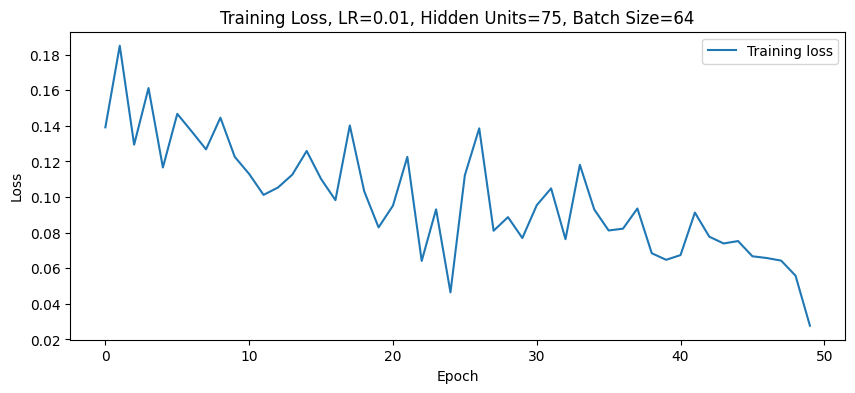

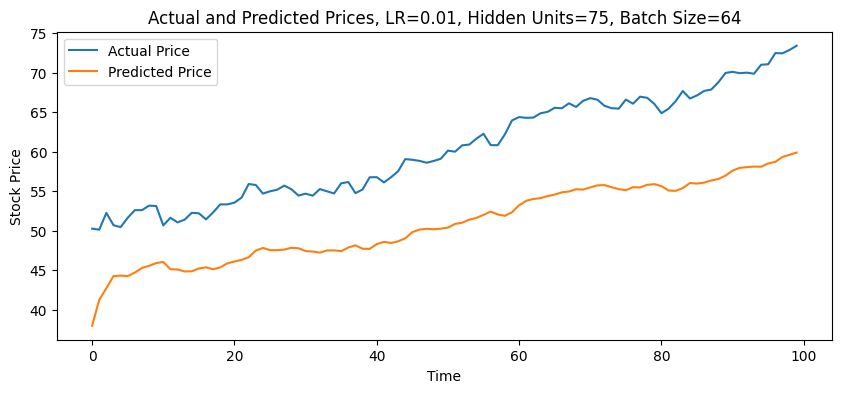

Training with LR=0.01, Hidden Units=100, Batch Size=10
Epoch 1 Loss: 0.032577112317085266
Epoch 2 Loss: 0.26957282423973083
Epoch 3 Loss: 0.05179040879011154
Epoch 4 Loss: 0.053437985479831696
Epoch 5 Loss: 0.08541461080312729
Epoch 6 Loss: 0.1275804340839386
Epoch 7 Loss: 0.08385290950536728
Epoch 8 Loss: 0.07293020188808441
Epoch 9 Loss: 0.06213580444455147
Epoch 10 Loss: 0.04040573537349701
Epoch 11 Loss: 0.014311638660728931
Epoch 12 Loss: 0.03134535625576973
Epoch 13 Loss: 0.050270479172468185
Epoch 14 Loss: 0.012491980567574501
Epoch 15 Loss: 0.014371460303664207
Epoch 16 Loss: 0.027212973684072495
Epoch 17 Loss: 0.009526200592517853
Epoch 18 Loss: 0.024797828868031502
Epoch 19 Loss: 0.03304402530193329
Epoch 20 Loss: 0.007140332367271185
Epoch 21 Loss: 0.014907578937709332
Epoch 22 Loss: 0.0018981382017955184
Epoch 23 Loss: 0.008511843159794807
Epoch 24 Loss: 0.007239880505949259
Epoch 25 Loss: 0.004709184169769287
Epoch 26 Loss: 0.014312757179141045
Epoch 27 Loss: 0.01506452076

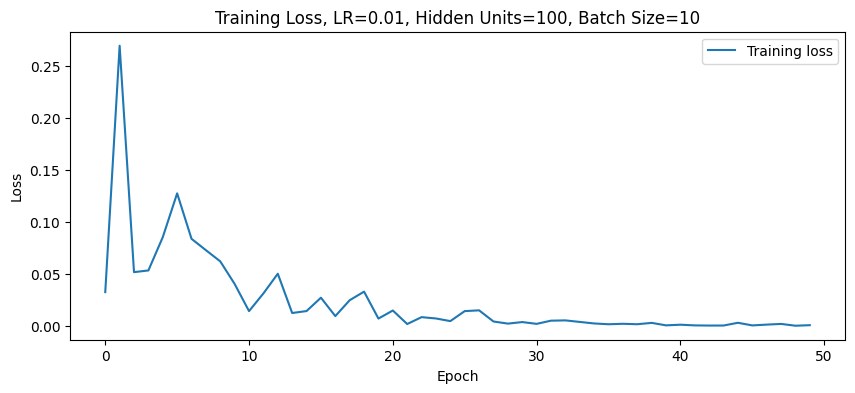

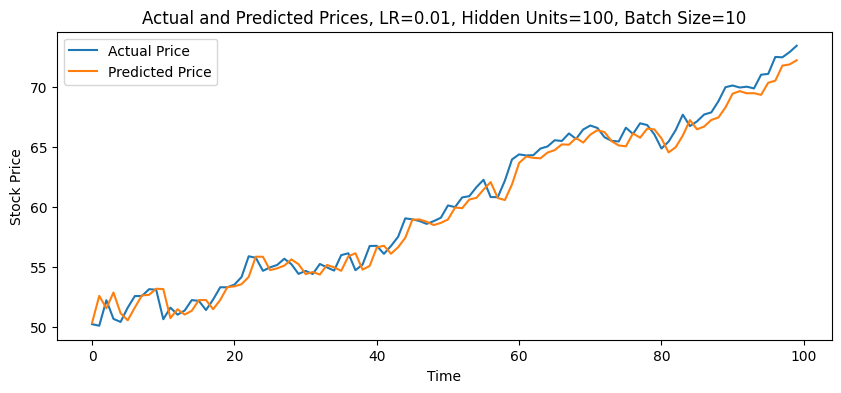

Training with LR=0.01, Hidden Units=100, Batch Size=16
Epoch 1 Loss: 0.21829666197299957
Epoch 2 Loss: 0.11247947067022324
Epoch 3 Loss: 0.13111485540866852
Epoch 4 Loss: 0.12238041311502457
Epoch 5 Loss: 0.10049735009670258
Epoch 6 Loss: 0.10299502313137054
Epoch 7 Loss: 0.06051997095346451
Epoch 8 Loss: 0.06769763678312302
Epoch 9 Loss: 0.05744054540991783
Epoch 10 Loss: 0.045660488307476044
Epoch 11 Loss: 0.08394038677215576
Epoch 12 Loss: 0.03987474367022514
Epoch 13 Loss: 0.04609756916761398
Epoch 14 Loss: 0.03957279399037361
Epoch 15 Loss: 0.05429404228925705
Epoch 16 Loss: 0.022660044953227043
Epoch 17 Loss: 0.03500601276755333
Epoch 18 Loss: 0.025771910324692726
Epoch 19 Loss: 0.021533405408263206
Epoch 20 Loss: 0.026912758126854897
Epoch 21 Loss: 0.021552201360464096
Epoch 22 Loss: 0.014002997428178787
Epoch 23 Loss: 0.022257141768932343
Epoch 24 Loss: 0.021848144009709358
Epoch 25 Loss: 0.009874148294329643
Epoch 26 Loss: 0.02233779802918434
Epoch 27 Loss: 0.00822774227708578

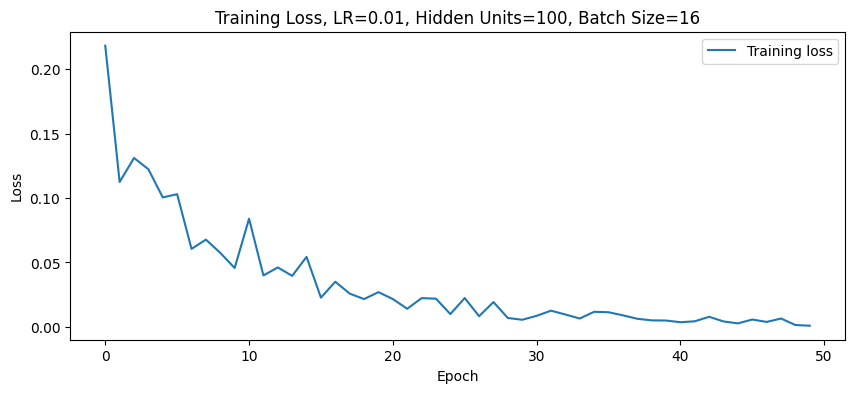

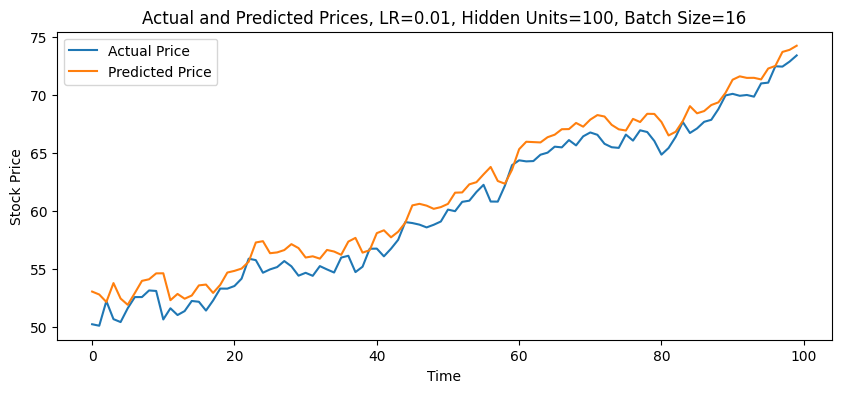

Training with LR=0.01, Hidden Units=100, Batch Size=32
Epoch 1 Loss: 0.1650063544511795
Epoch 2 Loss: 0.13885004818439484
Epoch 3 Loss: 0.12145175784826279
Epoch 4 Loss: 0.1532091647386551
Epoch 5 Loss: 0.07503209263086319
Epoch 6 Loss: 0.16230803728103638
Epoch 7 Loss: 0.10838086903095245
Epoch 8 Loss: 0.1466747224330902
Epoch 9 Loss: 0.14792467653751373
Epoch 10 Loss: 0.07993517816066742
Epoch 11 Loss: 0.07076691091060638
Epoch 12 Loss: 0.10555215924978256
Epoch 13 Loss: 0.09310927987098694
Epoch 14 Loss: 0.13652092218399048
Epoch 15 Loss: 0.056269288063049316
Epoch 16 Loss: 0.10081671178340912
Epoch 17 Loss: 0.14256437122821808
Epoch 18 Loss: 0.06455232203006744
Epoch 19 Loss: 0.06565196812152863
Epoch 20 Loss: 0.04432179778814316
Epoch 21 Loss: 0.06772922724485397
Epoch 22 Loss: 0.08683343231678009
Epoch 23 Loss: 0.052032340317964554
Epoch 24 Loss: 0.09116332232952118
Epoch 25 Loss: 0.11617454141378403
Epoch 26 Loss: 0.09807126969099045
Epoch 27 Loss: 0.06504503637552261
Epoch 28 L

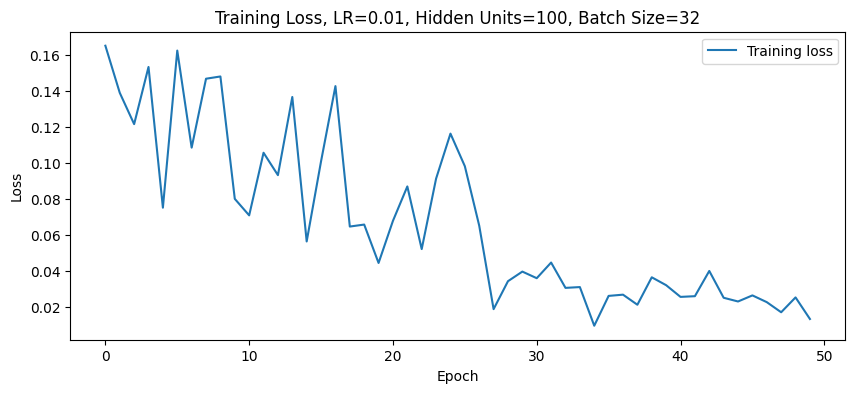

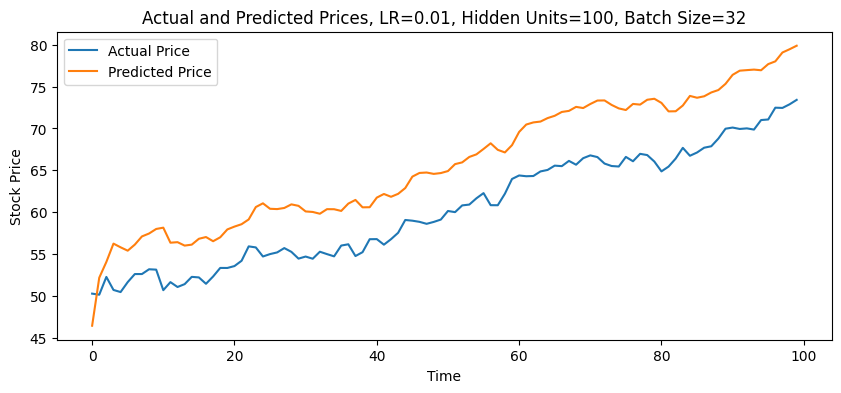

Training with LR=0.01, Hidden Units=100, Batch Size=64
Epoch 1 Loss: 0.178732767701149
Epoch 2 Loss: 0.14241360127925873
Epoch 3 Loss: 0.11270900815725327
Epoch 4 Loss: 0.12254392355680466
Epoch 5 Loss: 0.1313442438840866
Epoch 6 Loss: 0.13205736875534058
Epoch 7 Loss: 0.1394689530134201
Epoch 8 Loss: 0.12835745513439178
Epoch 9 Loss: 0.108519546687603
Epoch 10 Loss: 0.16327153146266937
Epoch 11 Loss: 0.12572315335273743
Epoch 12 Loss: 0.111691415309906
Epoch 13 Loss: 0.07382604479789734
Epoch 14 Loss: 0.10465598851442337
Epoch 15 Loss: 0.11524467915296555
Epoch 16 Loss: 0.10336387157440186
Epoch 17 Loss: 0.11342468857765198
Epoch 18 Loss: 0.12987631559371948
Epoch 19 Loss: 0.1140303686261177
Epoch 20 Loss: 0.09719676524400711
Epoch 21 Loss: 0.10008854418992996
Epoch 22 Loss: 0.13592489063739777
Epoch 23 Loss: 0.10600494593381882
Epoch 24 Loss: 0.1050737276673317
Epoch 25 Loss: 0.10083193331956863
Epoch 26 Loss: 0.07615220546722412
Epoch 27 Loss: 0.12539537250995636
Epoch 28 Loss: 0.11

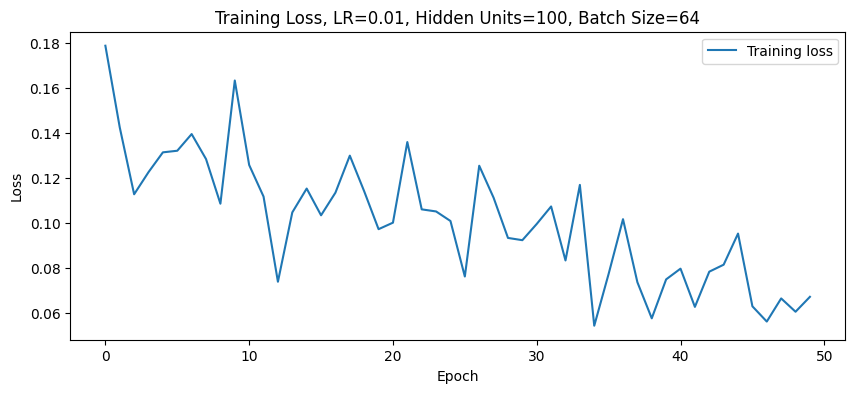

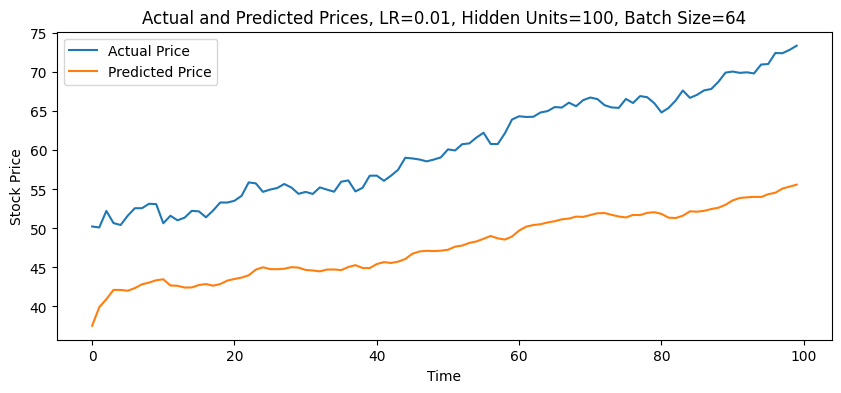

Training with LR=0.1, Hidden Units=50, Batch Size=10
Epoch 1 Loss: 0.05819582939147949
Epoch 2 Loss: 0.02029380574822426
Epoch 3 Loss: 0.0030020265839993954
Epoch 4 Loss: 0.0013449856778606772
Epoch 5 Loss: 0.0014696985017508268
Epoch 6 Loss: 0.00036309927236288786
Epoch 7 Loss: 0.0003522130136843771
Epoch 8 Loss: 0.000307685520965606
Epoch 9 Loss: 0.0010334088001400232
Epoch 10 Loss: 4.521587834460661e-05
Epoch 11 Loss: 0.00024927593767642975
Epoch 12 Loss: 0.00024194768047891557
Epoch 13 Loss: 0.0006194080924615264
Epoch 14 Loss: 0.00028120438219048083
Epoch 15 Loss: 5.334904562914744e-05
Epoch 16 Loss: 0.00021338497754186392
Epoch 17 Loss: 0.00013295550888869911
Epoch 18 Loss: 4.4339562009554356e-05
Epoch 19 Loss: 0.0007454321603290737
Epoch 20 Loss: 0.0010113402968272567
Epoch 21 Loss: 0.000774316256865859
Epoch 22 Loss: 0.00015732762403786182
Epoch 23 Loss: 2.3700511519564316e-05
Epoch 24 Loss: 0.0010027732932940125
Epoch 25 Loss: 0.00011878528312081471
Epoch 26 Loss: 5.9821068134

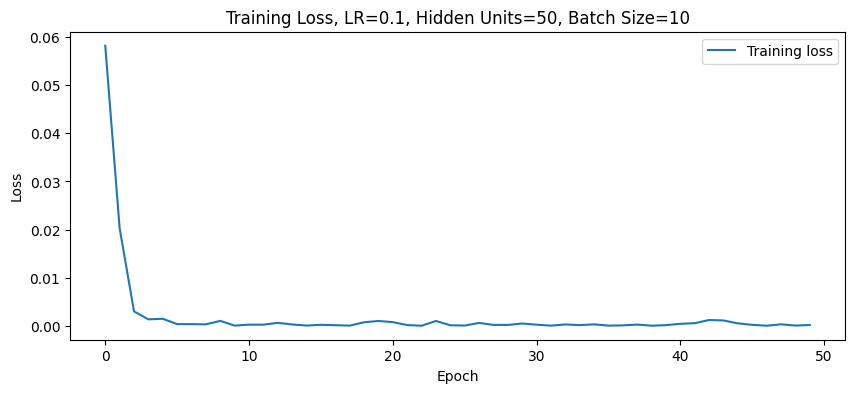

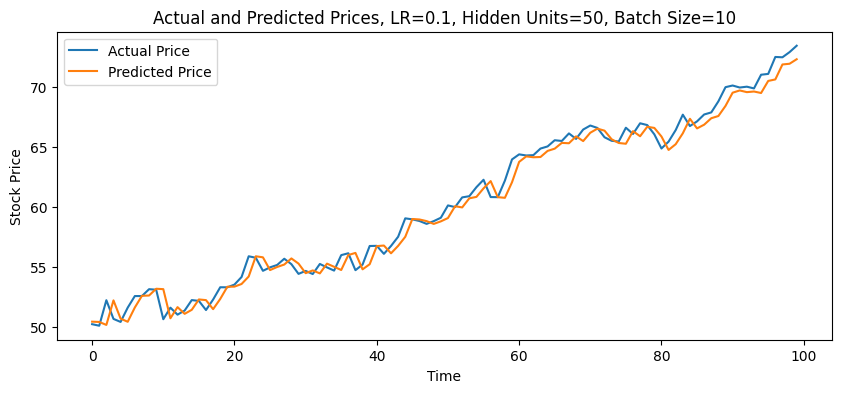

Training with LR=0.1, Hidden Units=50, Batch Size=16
Epoch 1 Loss: 0.04096285626292229
Epoch 2 Loss: 0.028337297961115837
Epoch 3 Loss: 0.009145679883658886
Epoch 4 Loss: 0.007175216916948557
Epoch 5 Loss: 0.002134327543899417
Epoch 6 Loss: 0.0016440576873719692
Epoch 7 Loss: 0.000685955339577049
Epoch 8 Loss: 0.00034609963768161833
Epoch 9 Loss: 0.00017089580069296062
Epoch 10 Loss: 0.0003014983667526394
Epoch 11 Loss: 0.0005845928099006414
Epoch 12 Loss: 0.00011826671106973663
Epoch 13 Loss: 0.00027387458248995245
Epoch 14 Loss: 0.00036396991345100105
Epoch 15 Loss: 0.0005551211652345955
Epoch 16 Loss: 0.0010340225417166948
Epoch 17 Loss: 0.00013560443767346442
Epoch 18 Loss: 0.00019407153013162315
Epoch 19 Loss: 0.00019729483756236732
Epoch 20 Loss: 0.0003407296899240464
Epoch 21 Loss: 0.0006083942134864628
Epoch 22 Loss: 0.00015001551946625113
Epoch 23 Loss: 0.00030344765400514007
Epoch 24 Loss: 5.9482656070031226e-05
Epoch 25 Loss: 0.00027012580540031195
Epoch 26 Loss: 0.000267148

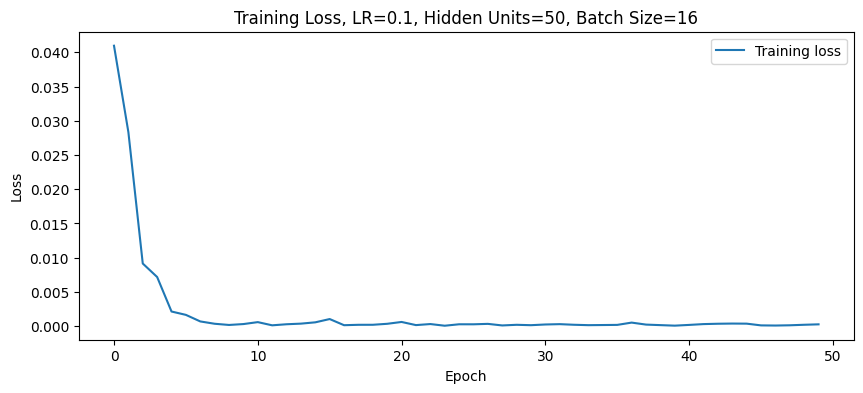

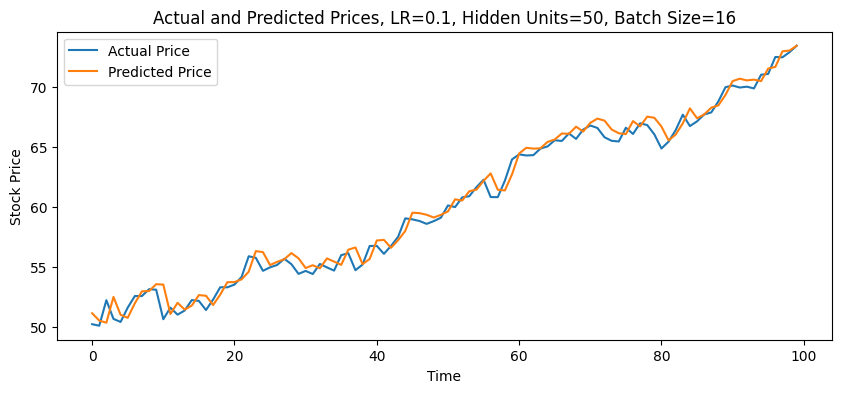

Training with LR=0.1, Hidden Units=50, Batch Size=32
Epoch 1 Loss: 0.13682995736598969
Epoch 2 Loss: 0.07736494392156601
Epoch 3 Loss: 0.035873349756002426
Epoch 4 Loss: 0.029048731550574303
Epoch 5 Loss: 0.019544625654816628
Epoch 6 Loss: 0.01570926047861576
Epoch 7 Loss: 0.012168671004474163
Epoch 8 Loss: 0.003813644638285041
Epoch 9 Loss: 0.002841372275725007
Epoch 10 Loss: 0.0032789106480777264
Epoch 11 Loss: 0.0023334764409810305
Epoch 12 Loss: 0.0020416986662894487
Epoch 13 Loss: 0.0016868062084540725
Epoch 14 Loss: 0.0007918495684862137
Epoch 15 Loss: 0.0007696027751080692
Epoch 16 Loss: 0.00029648473719134927
Epoch 17 Loss: 0.000533212732989341
Epoch 18 Loss: 0.0006536394939757884
Epoch 19 Loss: 0.0002556047111283988
Epoch 20 Loss: 0.0010379384038969874
Epoch 21 Loss: 0.0004467903927434236
Epoch 22 Loss: 0.00018851183995138854
Epoch 23 Loss: 0.0005662431358359754
Epoch 24 Loss: 0.00037412127130664885
Epoch 25 Loss: 0.0003342012350913137
Epoch 26 Loss: 0.0002648154622875154
Epoc

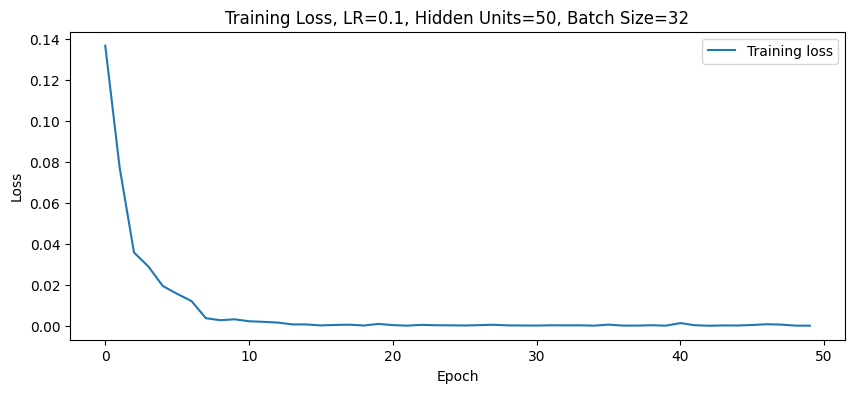

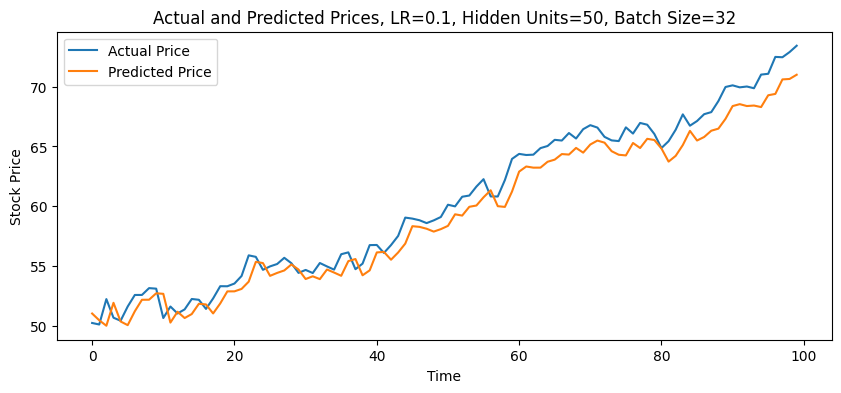

Training with LR=0.1, Hidden Units=50, Batch Size=64
Epoch 1 Loss: 0.0870748907327652
Epoch 2 Loss: 0.11120987683534622
Epoch 3 Loss: 0.09520089626312256
Epoch 4 Loss: 0.1068451926112175
Epoch 5 Loss: 0.05857689306139946
Epoch 6 Loss: 0.04045546427369118
Epoch 7 Loss: 0.03364972025156021
Epoch 8 Loss: 0.02860252931714058
Epoch 9 Loss: 0.01750878617167473
Epoch 10 Loss: 0.02032710798084736
Epoch 11 Loss: 0.01423922274261713
Epoch 12 Loss: 0.012401142157614231
Epoch 13 Loss: 0.006910366006195545
Epoch 14 Loss: 0.008763588964939117
Epoch 15 Loss: 0.005382730159908533
Epoch 16 Loss: 0.005148062948137522
Epoch 17 Loss: 0.005959602538496256
Epoch 18 Loss: 0.003961609210819006
Epoch 19 Loss: 0.003081058617681265
Epoch 20 Loss: 0.002300690393894911
Epoch 21 Loss: 0.0022434156853705645
Epoch 22 Loss: 0.0017684767954051495
Epoch 23 Loss: 0.0015420400304719806
Epoch 24 Loss: 0.001240537385456264
Epoch 25 Loss: 0.001258178148418665
Epoch 26 Loss: 0.0010769045911729336
Epoch 27 Loss: 0.001026779646

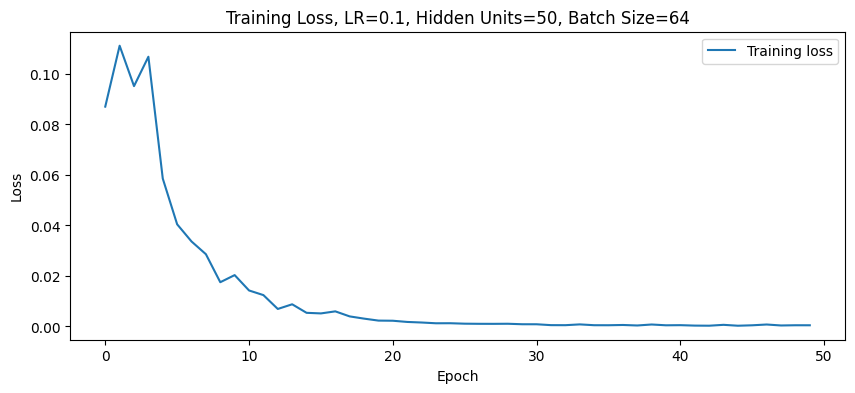

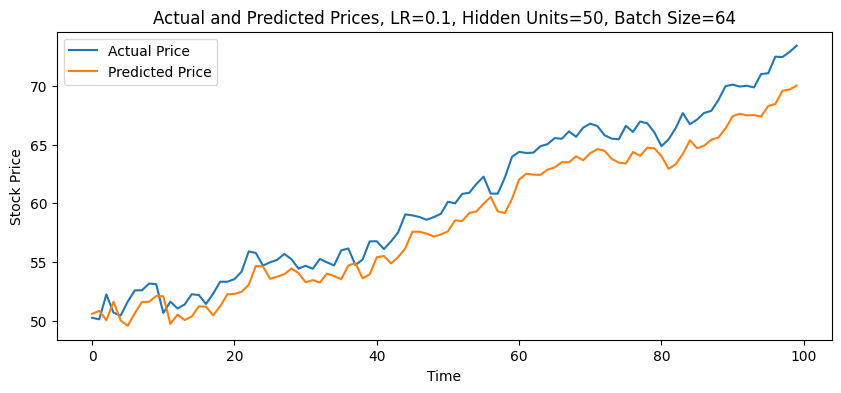

Training with LR=0.1, Hidden Units=75, Batch Size=10
Epoch 1 Loss: 0.030031263828277588
Epoch 2 Loss: 0.0063067832961678505
Epoch 3 Loss: 0.005749216303229332
Epoch 4 Loss: 0.002190016210079193
Epoch 5 Loss: 0.0001572752807987854
Epoch 6 Loss: 0.0007270163623616099
Epoch 7 Loss: 0.00012076595157850534
Epoch 8 Loss: 0.0001691321813268587
Epoch 9 Loss: 0.00013906373351346701
Epoch 10 Loss: 0.0003738251398317516
Epoch 11 Loss: 0.0007513046730309725
Epoch 12 Loss: 4.561688911053352e-05
Epoch 13 Loss: 6.143520295154303e-05
Epoch 14 Loss: 8.421565871685743e-05
Epoch 15 Loss: 7.856570300646126e-05
Epoch 16 Loss: 6.381923594744876e-05
Epoch 17 Loss: 0.0005641707684844732
Epoch 18 Loss: 0.00015495807747356594
Epoch 19 Loss: 0.0003108405217062682
Epoch 20 Loss: 1.5098284166015219e-05
Epoch 21 Loss: 0.00011228957737330347
Epoch 22 Loss: 0.00010670445772120729
Epoch 23 Loss: 5.1908125897170976e-05
Epoch 24 Loss: 3.837995609501377e-05
Epoch 25 Loss: 4.6203018428059295e-05
Epoch 26 Loss: 0.000319991

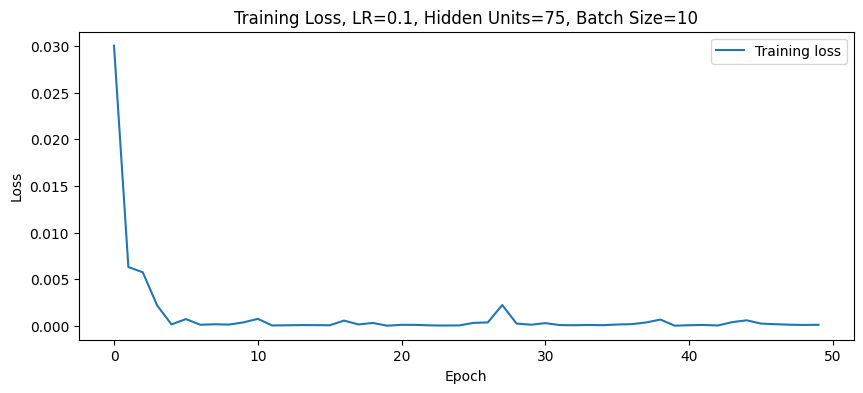

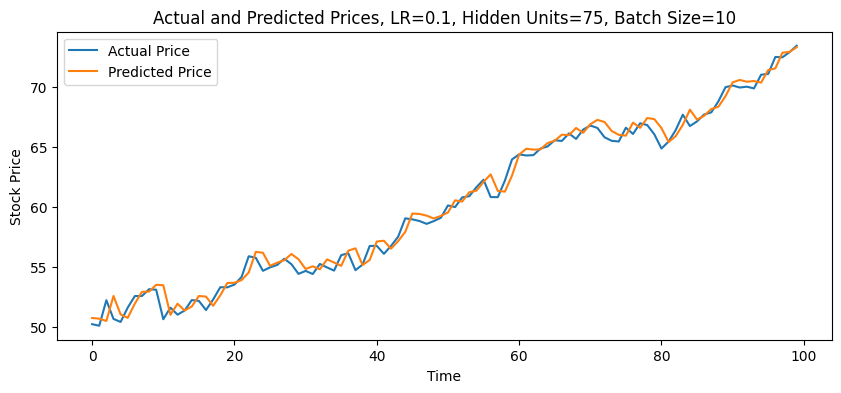

Training with LR=0.1, Hidden Units=75, Batch Size=16
Epoch 1 Loss: 0.10504061728715897
Epoch 2 Loss: 0.01984296552836895
Epoch 3 Loss: 0.014152857474982738
Epoch 4 Loss: 0.005317209288477898
Epoch 5 Loss: 0.0024082569871097803
Epoch 6 Loss: 0.0012378388782963157
Epoch 7 Loss: 0.001489009940996766
Epoch 8 Loss: 0.0011101017007604241
Epoch 9 Loss: 0.0005464275600388646
Epoch 10 Loss: 0.0005763075896538794
Epoch 11 Loss: 0.0007846661028452218
Epoch 12 Loss: 0.0005264533683657646
Epoch 13 Loss: 0.0004808434168808162
Epoch 14 Loss: 0.00026937975781038404
Epoch 15 Loss: 0.0004932039300911129
Epoch 16 Loss: 0.00016507695545442402
Epoch 17 Loss: 0.00028209746233187616
Epoch 18 Loss: 0.0004593265475705266
Epoch 19 Loss: 0.00010383144399384037
Epoch 20 Loss: 0.00015906851331237704
Epoch 21 Loss: 0.00013089091225992888
Epoch 22 Loss: 0.00032527584698982537
Epoch 23 Loss: 0.00047970280866138637
Epoch 24 Loss: 0.00013422456686384976
Epoch 25 Loss: 0.00027355397469364107
Epoch 26 Loss: 0.00023678691

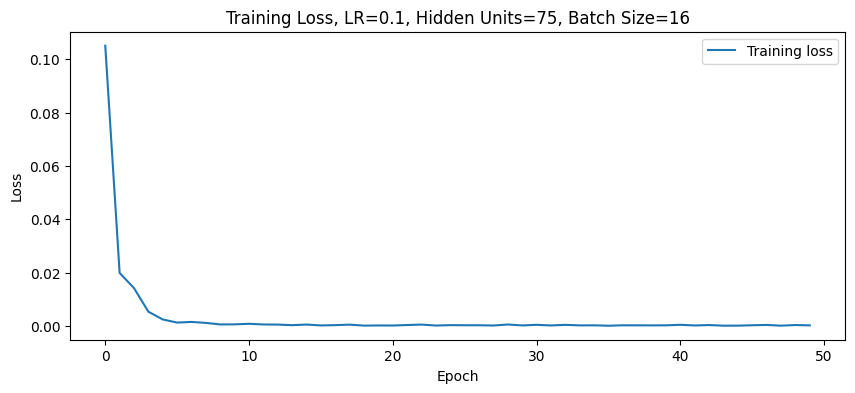

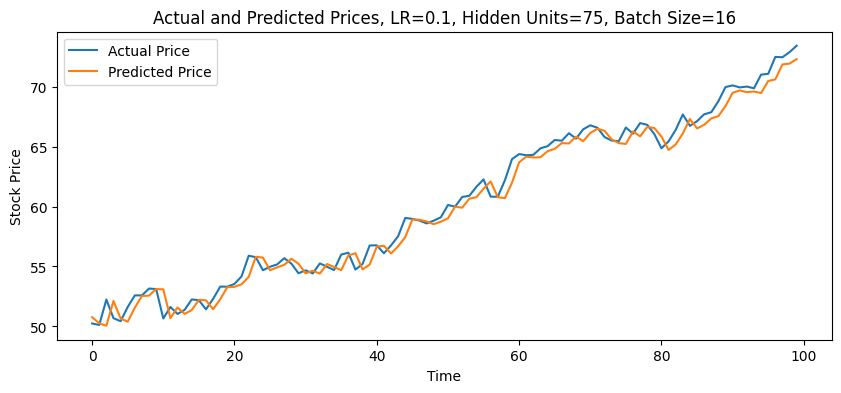

Training with LR=0.1, Hidden Units=75, Batch Size=32
Epoch 1 Loss: 0.11301504820585251
Epoch 2 Loss: 0.07723396271467209
Epoch 3 Loss: 0.021607927978038788
Epoch 4 Loss: 0.026861824095249176
Epoch 5 Loss: 0.023308685049414635
Epoch 6 Loss: 0.01994386315345764
Epoch 7 Loss: 0.010185373947024345
Epoch 8 Loss: 0.00923729594796896
Epoch 9 Loss: 0.007448483724147081
Epoch 10 Loss: 0.002338692080229521
Epoch 11 Loss: 0.000925365078728646
Epoch 12 Loss: 0.0005657143192365766
Epoch 13 Loss: 0.0015391104388982058
Epoch 14 Loss: 0.0007033298606984317
Epoch 15 Loss: 0.0005429961020126939
Epoch 16 Loss: 0.0011649559019133449
Epoch 17 Loss: 0.0009426151518709958
Epoch 18 Loss: 0.00032934482442215085
Epoch 19 Loss: 0.00022649580205325037
Epoch 20 Loss: 0.0003324522986076772
Epoch 21 Loss: 0.0003050899540539831
Epoch 22 Loss: 0.00012329914898145944
Epoch 23 Loss: 0.0005604780162684619
Epoch 24 Loss: 0.0002587303752079606
Epoch 25 Loss: 0.0006574466242454946
Epoch 26 Loss: 0.00015106279170140624
Epoch

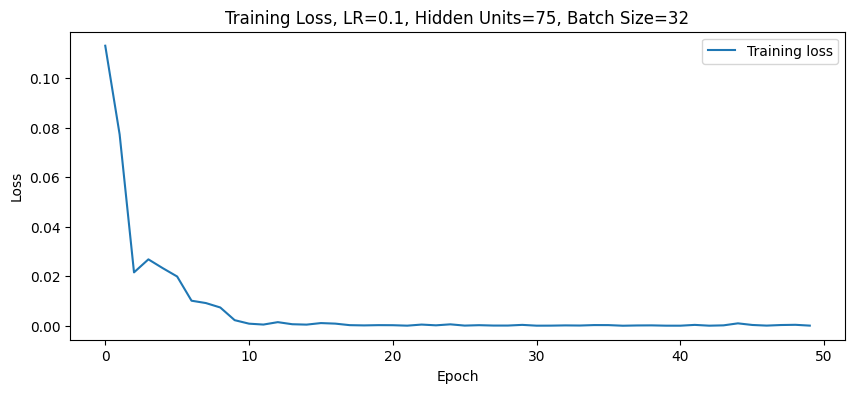

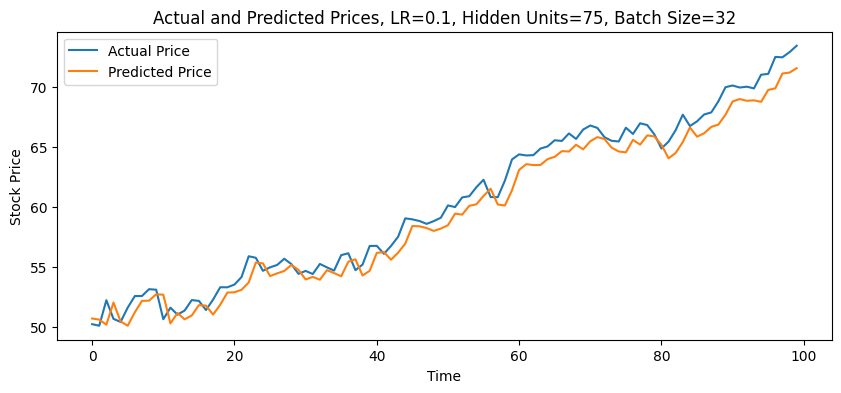

Training with LR=0.1, Hidden Units=75, Batch Size=64
Epoch 1 Loss: 0.1162407323718071
Epoch 2 Loss: 0.09342338889837265
Epoch 3 Loss: 0.11183365434408188
Epoch 4 Loss: 0.07040154933929443
Epoch 5 Loss: 0.05269366502761841
Epoch 6 Loss: 0.04244641587138176
Epoch 7 Loss: 0.04229605570435524
Epoch 8 Loss: 0.020157841965556145
Epoch 9 Loss: 0.019869817420840263
Epoch 10 Loss: 0.020006859675049782
Epoch 11 Loss: 0.016406940296292305
Epoch 12 Loss: 0.009366015903651714
Epoch 13 Loss: 0.014863487333059311
Epoch 14 Loss: 0.008711708709597588
Epoch 15 Loss: 0.0067853485234081745
Epoch 16 Loss: 0.00812624953687191
Epoch 17 Loss: 0.00388694042339921
Epoch 18 Loss: 0.004363297019153833
Epoch 19 Loss: 0.0029608544427901506
Epoch 20 Loss: 0.0035597675014287233
Epoch 21 Loss: 0.0027722313534468412
Epoch 22 Loss: 0.001972109079360962
Epoch 23 Loss: 0.0012616801541298628
Epoch 24 Loss: 0.0015259289648383856
Epoch 25 Loss: 0.0007408090750686824
Epoch 26 Loss: 0.001301768934354186
Epoch 27 Loss: 0.000977

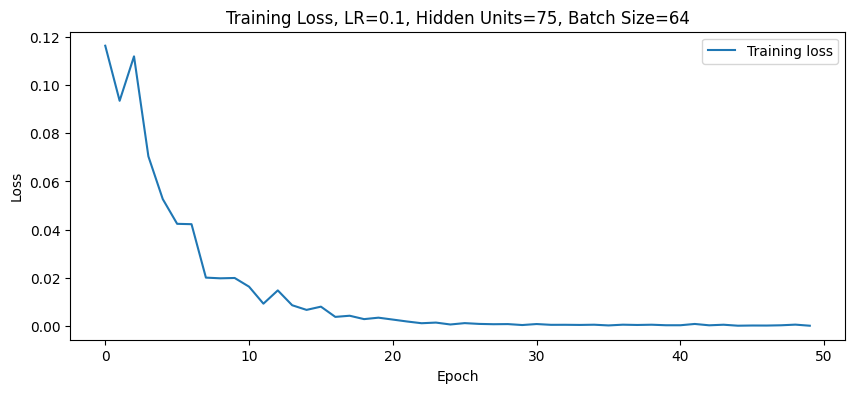

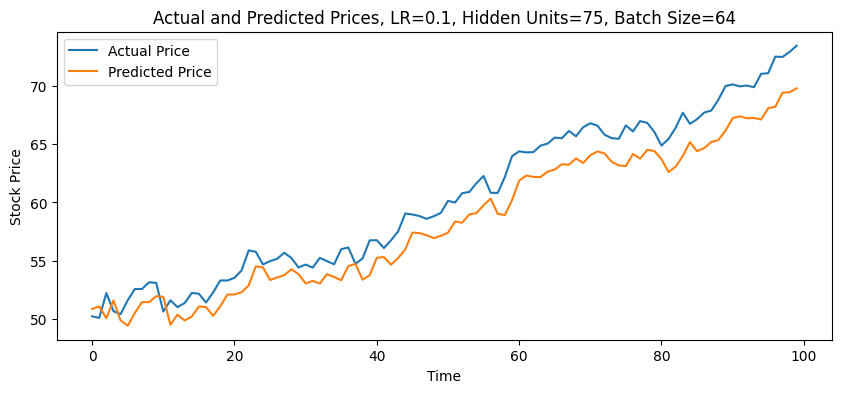

Training with LR=0.1, Hidden Units=100, Batch Size=10
Epoch 1 Loss: 0.02551257237792015
Epoch 2 Loss: 0.005868889391422272
Epoch 3 Loss: 0.002235136227682233
Epoch 4 Loss: 0.0012626796960830688
Epoch 5 Loss: 0.00040857616113498807
Epoch 6 Loss: 1.926879122038372e-05
Epoch 7 Loss: 8.784297824604437e-05
Epoch 8 Loss: 7.245484448503703e-05
Epoch 9 Loss: 0.00018515478586778045
Epoch 10 Loss: 8.048802556004375e-05
Epoch 11 Loss: 5.618477734969929e-05
Epoch 12 Loss: 0.00027986496570520103
Epoch 13 Loss: 0.00012397718091960996
Epoch 14 Loss: 0.00029279207228682935
Epoch 15 Loss: 0.00026112928753718734
Epoch 16 Loss: 0.0002931755152530968
Epoch 17 Loss: 0.00015390870976261795
Epoch 18 Loss: 0.00011335543968016282
Epoch 19 Loss: 1.946628799487371e-05
Epoch 20 Loss: 8.57906270539388e-05
Epoch 21 Loss: 0.0009385370649397373
Epoch 22 Loss: 0.00031509093241766095
Epoch 23 Loss: 0.00019803321629296988
Epoch 24 Loss: 0.00016681994020473212
Epoch 25 Loss: 2.7028047043131664e-05
Epoch 26 Loss: 0.000295

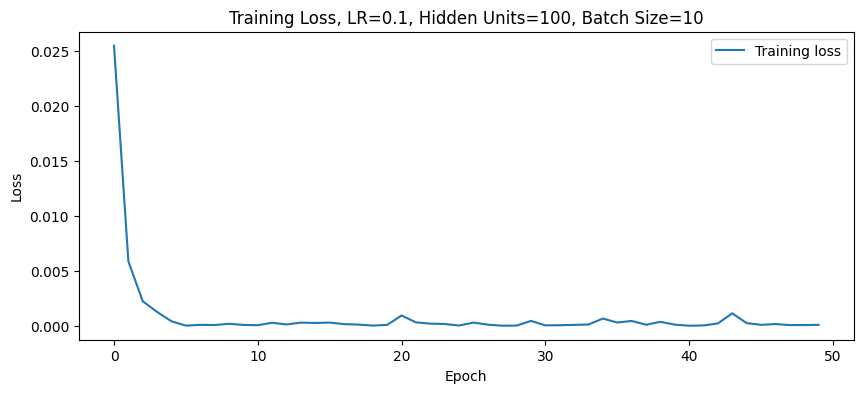

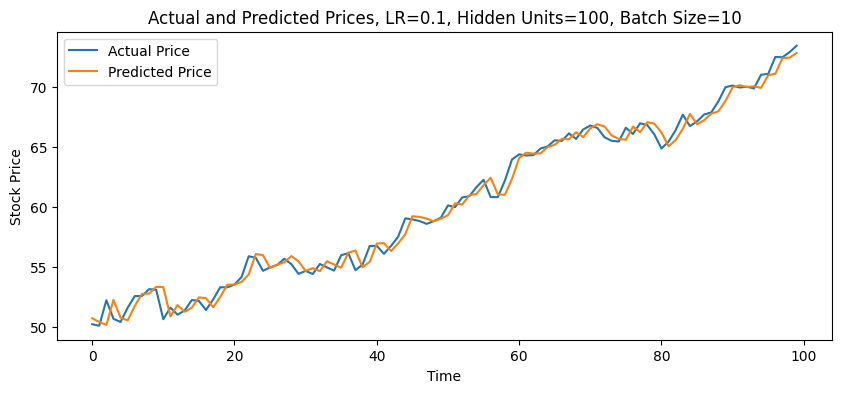

Training with LR=0.1, Hidden Units=100, Batch Size=16
Epoch 1 Loss: 0.07082021236419678
Epoch 2 Loss: 0.023438988253474236
Epoch 3 Loss: 0.012946395203471184
Epoch 4 Loss: 0.0035735969431698322
Epoch 5 Loss: 0.004906566347926855
Epoch 6 Loss: 0.0024199923500418663
Epoch 7 Loss: 0.002048920141533017
Epoch 8 Loss: 0.0003120360488537699
Epoch 9 Loss: 0.0006482401513494551
Epoch 10 Loss: 0.00028263352578505874
Epoch 11 Loss: 0.0004600999818649143
Epoch 12 Loss: 0.00012379183317534626
Epoch 13 Loss: 0.000558833300601691
Epoch 14 Loss: 0.0002635721757542342
Epoch 15 Loss: 0.0002800505026243627
Epoch 16 Loss: 0.000198438749066554
Epoch 17 Loss: 0.00021590311371255666
Epoch 18 Loss: 0.00028645459678955376
Epoch 19 Loss: 0.00016354216495528817
Epoch 20 Loss: 5.846579733770341e-05
Epoch 21 Loss: 0.00027426594169810414
Epoch 22 Loss: 0.0002123542653862387
Epoch 23 Loss: 0.00018959543376695365
Epoch 24 Loss: 0.0003994175640400499
Epoch 25 Loss: 0.00013255889643914998
Epoch 26 Loss: 9.2335125373210

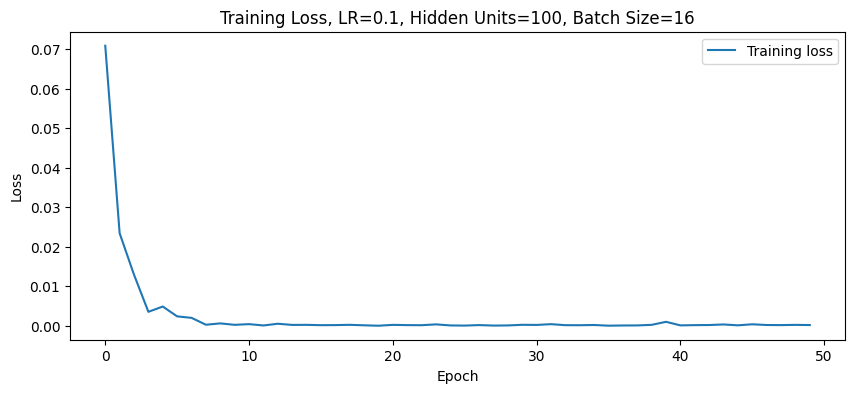

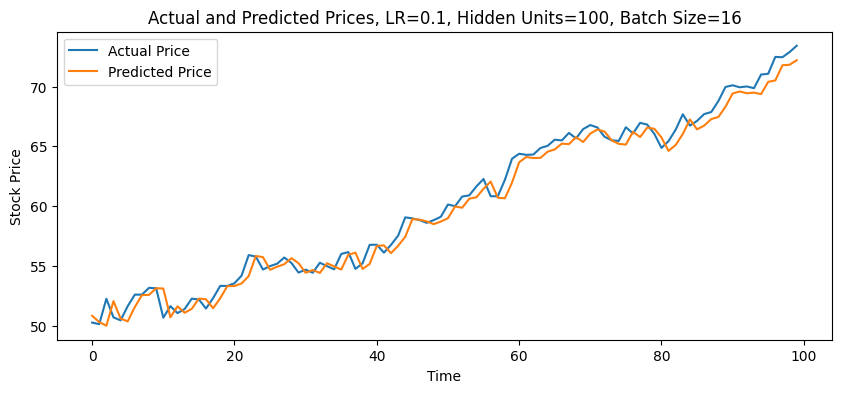

Training with LR=0.1, Hidden Units=100, Batch Size=32
Epoch 1 Loss: 0.10375995934009552
Epoch 2 Loss: 0.0852583795785904
Epoch 3 Loss: 0.06957843154668808
Epoch 4 Loss: 0.029540451243519783
Epoch 5 Loss: 0.0248692836612463
Epoch 6 Loss: 0.009525086730718613
Epoch 7 Loss: 0.007818872109055519
Epoch 8 Loss: 0.0076026455499231815
Epoch 9 Loss: 0.003068596590310335
Epoch 10 Loss: 0.0015720307128503919
Epoch 11 Loss: 0.0030867743771523237
Epoch 12 Loss: 0.003153574885800481
Epoch 13 Loss: 0.0012879468267783523
Epoch 14 Loss: 0.0011642725439742208
Epoch 15 Loss: 0.0005942016141489148
Epoch 16 Loss: 0.0006701029487885535
Epoch 17 Loss: 0.00041790580144152045
Epoch 18 Loss: 0.0003625595709308982
Epoch 19 Loss: 0.0008791749714873731
Epoch 20 Loss: 0.0005599256255663931
Epoch 21 Loss: 0.0003142469795420766
Epoch 22 Loss: 0.00035789943649433553
Epoch 23 Loss: 0.0003066749486606568
Epoch 24 Loss: 0.0002359208301641047
Epoch 25 Loss: 0.00028955357265658677
Epoch 26 Loss: 0.00012104023335268721
Epoc

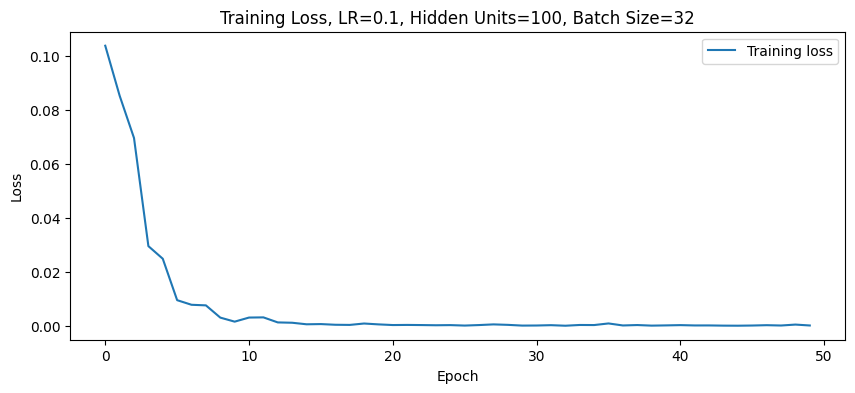

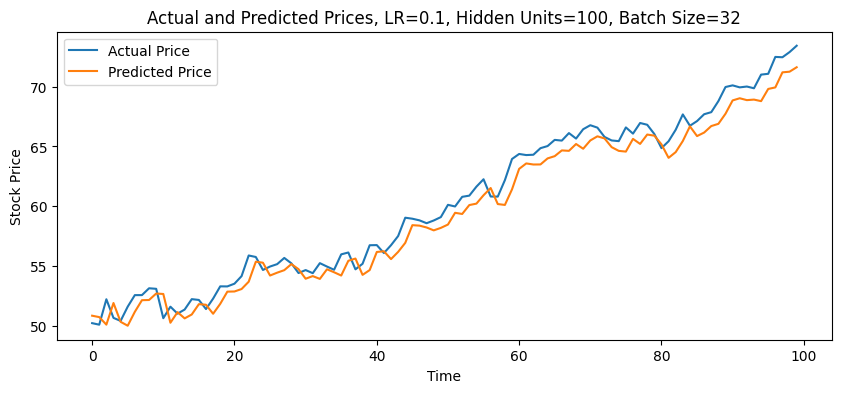

Training with LR=0.1, Hidden Units=100, Batch Size=64
Epoch 1 Loss: 0.12788686156272888
Epoch 2 Loss: 0.11522108316421509
Epoch 3 Loss: 0.08600834757089615
Epoch 4 Loss: 0.07132349908351898
Epoch 5 Loss: 0.0689549669623375
Epoch 6 Loss: 0.047954753041267395
Epoch 7 Loss: 0.04983885586261749
Epoch 8 Loss: 0.029734527692198753
Epoch 9 Loss: 0.017621655017137527
Epoch 10 Loss: 0.023780645802617073
Epoch 11 Loss: 0.01638353057205677
Epoch 12 Loss: 0.0135126281529665
Epoch 13 Loss: 0.01107674092054367
Epoch 14 Loss: 0.013347892090678215
Epoch 15 Loss: 0.01097481045871973
Epoch 16 Loss: 0.008976041339337826
Epoch 17 Loss: 0.004827779717743397
Epoch 18 Loss: 0.0032170459162443876
Epoch 19 Loss: 0.003823353908956051
Epoch 20 Loss: 0.0041328733786940575
Epoch 21 Loss: 0.002451530424878001
Epoch 22 Loss: 0.002417870331555605
Epoch 23 Loss: 0.0018971787067130208
Epoch 24 Loss: 0.0019184796838089824
Epoch 25 Loss: 0.0019371917005628347
Epoch 26 Loss: 0.0017690504901111126
Epoch 27 Loss: 0.00110695

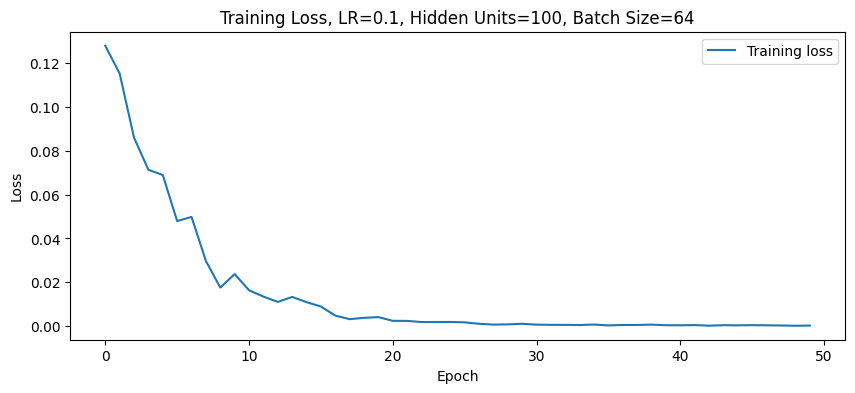

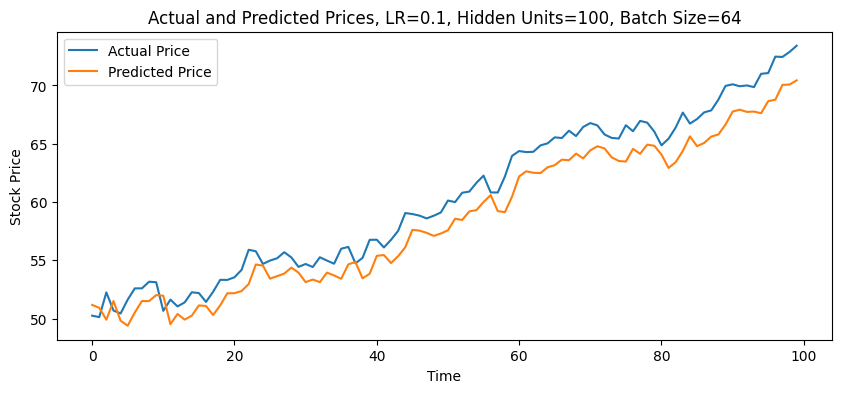

In [ ]:



# Training and evaluation loop
for lr in learning_rates:
    for hidden_units in hidden_layers:
        for batch_size in batch_sizes:
            print(f"Training with LR={lr}, Hidden Units={hidden_units}, Batch Size={batch_size}")

            model = StockLSTM(1, hidden_units, 1)
            loss_function = nn.MSELoss()
            optimizer = optim.SGD(model.parameters(), lr=lr)

            train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

            model.train()
            epochs = 50
            all_losses = []
            for epoch in range(epochs):
                for seq, labels in train_loader:
                    optimizer.zero_grad()
                    model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                                         torch.zeros(1, 1, model.hidden_layer_size))

                    y_pred = model(seq)
                    loss = loss_function(y_pred.flatten(), labels)
                    loss.backward()
                    optimizer.step()
                all_losses.append(loss.item())
                print(f'Epoch {epoch + 1} Loss: {loss.item()}')

            # Plot training loss
            plt.figure(figsize=(10, 4))
            plt.plot(all_losses, label='Training loss')
            plt.title(f'Training Loss, LR={lr}, Hidden Units={hidden_units}, Batch Size={batch_size}')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.show()

            # Predictions
            model.eval()
            with torch.no_grad():
                test_preds = model(X_test).view(-1).numpy()
            actual = scaler.inverse_transform(y_test.view(-1, 1).numpy())
            predicted = scaler.inverse_transform(test_preds.reshape(-1, 1))

            # Plot actual vs predicted
            plt.figure(figsize=(10, 4))
            plt.plot(actual, label='Actual Price')
            plt.plot(predicted, label='Predicted Price')
            plt.title(f'Actual and Predicted Prices, LR={lr}, Hidden Units={hidden_units}, Batch Size={batch_size}')
            plt.xlabel('Time')
            plt.ylabel('Stock Price')
            plt.legend()
            plt.show()

